In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc("font",size=16)

In [3]:
from scipy.optimize import minimize_scalar
from functools import partial

In [4]:
# Start sympy
from sympy import *
init_printing()
from IPython.display import display

In [5]:
from collections import OrderedDict

# Define symbols

Coordinates

In [6]:
xyz=x,y,z=symbols("x,y,z",real=True)

Solution variables

In [7]:
w,beta,q=symbols("omega,beta,q")

Material parameters

In [8]:
p,c11,c12,c13,c33,c44=matparams=symbols("p,c_11,c_12,c_13,c_33,c_44")
Cmat=Matrix([
        [c11,c12,c13,  0,  0,0],
        [c12,c11,c13,  0,  0,0],
        [c13,c13,c33,  0,  0,0],
        [  0,  0,  0,c44,  0,0],
        [  0,  0,  0,  0,c44,0],
        [  0,  0,  0,  0,  0,(c11-c12)/2]])

A convenience dictionary which can replace material params with specific symbols for GaN or AlN

In [9]:
mpsubs={
    'GaN': OrderedDict(zip(matparams,symbols([mpi.name+("G" if "_" in mpi.name else "_G") for mpi in matparams]))),
    'AlN': OrderedDict(zip(matparams,symbols([mpi.name+("A" if "_" in mpi.name else "_A") for mpi in matparams])))
}
pG,c11G,c12G,c13G,c33G,c44G=mpsubs['GaN'].values()
pA,c11A,c12A,c13A,c33A,c44A=mpsubs['AlN'].values()

# Eg for GaN
mpsubs['GaN']

In [10]:
Cmats={
    None: Cmat,
    'GaN':Cmat.subs(mpsubs['GaN']),
    'AlN':Cmat.subs(mpsubs['AlN'])}

Dictionary for numerical substitutions

In [11]:
GPa=1e9
nm=1e-9
gpcm3=1e-3/1e-6
from scipy.constants import hbar, e
numerics={
    c11G: 390 *GPa,
    c12G: 145 *GPa,
    c13G: 106 *GPa,
    c33G: 398 *GPa,
    c44G: 105 *GPa,
    pG:  6.15 *gpcm3,
    
    c11A: 396 *GPa,
    c12A: 137 *GPa,
    c13A: 108 *GPa,
    c33A: 373 *GPa,
    c44A: 116 *GPa,
    pA:  3.26 *gpcm3,
}

In [12]:
meV=e/hbar*1e-3

Translate index pairs to single Voigt notation index

In [13]:
order=[(x,x),(y,y),(z,z),(y,z),(x,z),(x,y)]
print("Ordering:")
display(order)

def getind(i,j):
    pair=(i,j)
    return order.index(tuple(sorted(pair,key=lambda x:x.name)))

# Eg index for xy is 5
getind(x,y)

Ordering:


# Bulk modes

A single component of a mode will have the following form, with an $x$-wavevector $q$ and out-of-plane $\beta$:

In [14]:
mode=exp(I*beta*z)*exp(I*q*x)
mode

A bulk mode $u_i$ will have that form for each component with some coefficient $D_i$, where $i$ ranges $\{x,y,z\}$

In [15]:
Dxyz=symbols("D_x,D_y,D_z")
def u_blk(i,r=None):
    """ Components for a bulk mode with coefficients $D_i$.
    
    Args:
        i: one of the symbols x, y, or z
        r: (normally specifies a region, ignored for bulk)
    """
    return Dxyz[xyz.index(i)]*mode
u_blk(x),u_blk(y),u_blk(z)

The strain $\epsilon_{ij}$ is a symmetric derivative of the components

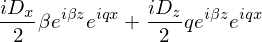

In [16]:
def S(u,i,j,r=None):
    """ Components of the strain tensor for the displacement function $u$.
    
    Args:
        u(k): a function returning the displacement component along $k$
        i,j: the indices (one of $\{x,y,z\}$) into the strain tensor
        r: region, passed to the displacement function
    """
    return Rational(1,2)*(diff(u(i,r),j)+diff(u(j,r),i))

# Example eps_xy
S(u_blk,x,z)

The stress component is related to the strain by the elastic tensor

In [17]:
def T(u,i,j,r=None,mat=None):
    """ Stress tensor component for displacement function $u$.
    
    Args:
        u(k): a function returning the displacement component along $k$
        i,j: the indices (one of $\{x,y,z\}$) into the stress tensor
        r: region, passed to the displacement function
    """
    
    # Get the six-component Voigt tuple
    Smat=Matrix([S(u,*o,r=r) for o in order])
    smat=diag(1,1,1,2,2,2)*Smat
    
    # Multiply by the Voigt form tensor
    return (Cmats[mat]*smat)[getind(i,j)]

# Example T_xx
T(u_blk,x,x)

The divergence of the stress tensor

In [18]:
def delT(u,i,r=None):
    """ Stress tensor divergence, component $i$.
    
    Args:
        u(k): a function returning the displacement component along $k$
        i: the indices (one of $\{x,y,z\}$) into the divergence of the stress tensor
        r: (region) passed to the displacement function
    """
    return simplify(sum(diff(T(u,i,j,r),j) for j in (x,y,z)))
delT(u_blk,z)

## Solving xz modes

Hooke's law matrix form (the matrix whose determinant should be zero)

\left[\begin{matrix}- \beta^{2} c_{44} - c_{11} q^{2} + \omega^{2} p & - \beta c_{13} q - \beta c_{44} q\\- \beta c_{13} q - \beta c_{44} q & - \beta^{2} c_{33} - c_{44} q^{2} + \omega^{2} p\end{matrix}\right]


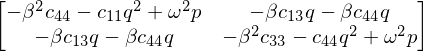

In [19]:
modematrix=Matrix([
    [expand(simplify((delT(u_blk,i)+p*w**2*u_blk(i))/exp(I*q*x)/exp(I*beta*z)))\
         .coeff(Dxyz[xyz.index(j)]) for j in [x,z]]\
    for i in [x,z]])
print(latex(modematrix))
modematrix

Determinant equation

In [20]:
print(latex(modematrix.det()))
modematrix.det()

- \left(- \beta c_{13} q - \beta c_{44} q\right)^{2} + \left(- \beta^{2} c_{33} - c_{44} q^{2} + \omega^{2} p\right) \left(- \beta^{2} c_{44} - c_{11} q^{2} + \omega^{2} p\right)


Coefficients of the determinant equation

In [21]:
B4=expand(modematrix.det()).coeff(beta,4)
B2=expand(modematrix.det()).coeff(beta,2)
B0=expand(modematrix.det()).coeff(beta,0)
print("B4:")
print(latex(B4))
display(B4)
print("\n\n")

print("B2:")
print(latex(B2))
display(B2)
print("\n\n")

print("B0:")
print(latex(factor(B0)))
display(factor(B0))

B4:
c_{33} c_{44}





B2:
c_{11} c_{33} q^{2} - c_{13}^{2} q^{2} - 2 c_{13} c_{44} q^{2} - c_{33} \omega^{2} p - c_{44} \omega^{2} p





B0:
\left(- c_{11} q^{2} + \omega^{2} p\right) \left(- c_{44} q^{2} + \omega^{2} p\right)


Dictionary to replace the symbols $\beta_{+1}$, $\beta_{-1}$ by the equations for the the two positive roots

In [22]:
Btwid=B2**2-4*B4*B0
betap,betam=symbols(r"{\beta_{+1}},{\beta_{-1}}")
betasubs={
    betap: sqrt(1/(2*B4)*(-B2+sqrt(Btwid))),
    betam: sqrt(1/(2*B4)*(-B2-sqrt(Btwid))),
}

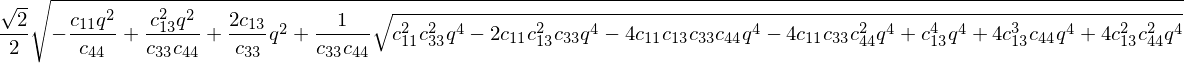

In [23]:
factor(expand(betasubs[betap].subs(w,0)))

Dictionary to replace symbols $\delta_{+1}$, $\delta_{-1}$ by the displacement ratios corresponding to the above two roots

In [24]:
deltap,deltam=symbols(r"{\delta_{+1}},{\delta_{-1}}")
deltasubs=dict(zip([deltap,deltam],
        [simplify((-modematrix[0,0]/modematrix[0,1]).subs(beta,betai)    .subs(betasubs))
         for betai in [betap,betam]]))

Dictionaries that do the above for material specific symbols (like $\beta_{Gp}$)

In [25]:
betaGp,betaGm,betaAp,betaAm=symbols(r"{\beta_{Gp}},{\beta_{Gm}},{\beta_{Ap}},{\beta_{Am}}")
deltaGp,deltaGm,deltaAp,deltaAm=symbols(r"{\delta_{Gp}},{\delta_{Gm}},{\delta_{Ap}},{\delta_{Am}}")
betasubsR={
    betaGp: betap.subs(betasubs).subs(mpsubs['GaN']),betaGm: betam.subs(betasubs).subs(mpsubs['GaN']),
    betaAp: betap.subs(betasubs).subs(mpsubs['AlN']),betaAm: betam.subs(betasubs).subs(mpsubs['AlN'])
}
deltasubsR={
    deltaGp: deltap.subs(deltasubs).subs(mpsubs['GaN']),deltaGm: deltam.subs(deltasubs).subs(mpsubs['GaN']),
    deltaAp: deltap.subs(deltasubs).subs(mpsubs['AlN']),deltaAm: deltam.subs(deltasubs).subs(mpsubs['AlN'])
}

predefining some symbols for later which will be coefficients of all four modes

In [26]:
DGpp,DGpm,DGmp,DGmm,DApp,DApm,DAmp,DAmm=symbols(r"{D^{+}_{+1G}},{D^{+}_{-1G}},{D^{-}_{+1G}},{D^{-}_{-1G}},{D^{+}_{+1A}},{D^{+}_{-1A}},{D^{-}_{+1A}},{D^{-}_{-1A}}")

Lamdified expressions for rapid evaluations of the above equations

In [27]:
l_betaAp=lambdify((q,w),betaAp.subs(betasubsR).subs(numerics))
l_betaAm=lambdify((q,w),betaAm.subs(betasubsR).subs(numerics))

In [28]:
l_deltaAp=lambdify((q,w),deltaAp.subs(deltasubsR).subs(numerics))
l_deltaAm=lambdify((q,w),deltaAm.subs(deltasubsR).subs(numerics))

In [29]:
l_betaGp=lambdify((q,w),betaGp.subs(betasubsR).subs(numerics))
l_betaGm=lambdify((q,w),betaGm.subs(betasubsR).subs(numerics))

In [30]:
l_deltaGp=lambdify((q,w),deltaGp.subs(deltasubsR).subs(numerics))
l_deltaGm=lambdify((q,w),deltaGm.subs(deltasubsR).subs(numerics))

### Showing $\beta$ is pure

In [31]:
P0=factor(expand(Btwid).coeff(q,0))/(p**2*w**4)
P2=simplify(expand(Btwid).coeff(q,2) /(p*w**2))
P4=factor(expand(Btwid).coeff(q,4))

print("P4:")
print(latex(P4))
display(P4)
print("\n\n")

print("P2:")
print(latex(P2))
display(P2)
print("\n\n")

print("P0:")
print(latex(P0))
display(P0)
print("\n\n")

P4:
\left(c_{11} c_{33} - c_{13}^{2}\right) \left(c_{11} c_{33} - c_{13}^{2} - 4 c_{13} c_{44} - 4 c_{44}^{2}\right)





P2:
- 2 c_{11} c_{33}^{2} + 2 c_{11} c_{33} c_{44} + 2 c_{13}^{2} c_{33} + 2 c_{13}^{2} c_{44} + 4 c_{13} c_{33} c_{44} + 4 c_{13} c_{44}^{2} + 4 c_{33} c_{44}^{2}





P0:
\left(c_{33} - c_{44}\right)^{2}


In [32]:
Ptwid=factor(P2**2-4*P4*P0)
print(latex(Ptwid))
Ptwid

- 16 c_{33} c_{44} \left(c_{13} + c_{44}\right)^{2} \left(c_{11} c_{33} - c_{11} c_{44} - c_{13}^{2} - 2 c_{13} c_{44} - c_{33} c_{44}\right)


THE LAST FACTOR IS >0 IF THE ANISOTROPY FACTOR IS <1, which is true

See Table 5 of Qin et al doi.org/10.3390/ma10121419

In [33]:
Ptwid.subs(mpsubs['GaN']).subs(numerics)

## Check bulk modes

In [34]:
lambdify((q,w),B0.subs(mpsubs['AlN']).subs(numerics))(1,1)

False
False


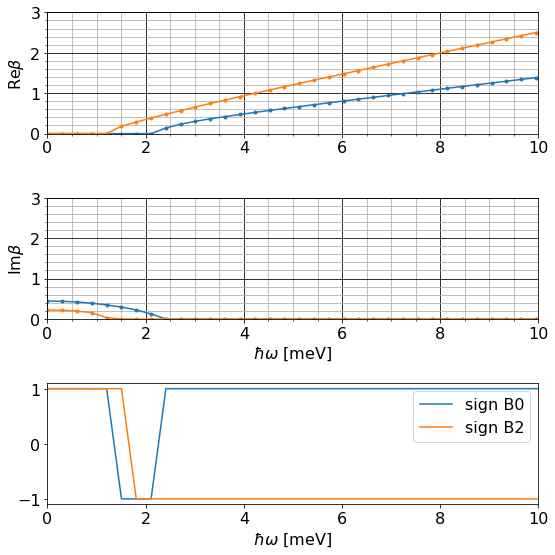

In [35]:
l_B0=lambdify((q,w),B0.subs(mpsubs['AlN']).subs(numerics))
l_B2=lambdify((q,w),B2.subs(mpsubs['AlN']).subs(numerics))
l_B4=lambdify((q,w),B4.subs(mpsubs['AlN']).subs(numerics))
def _():
    plt.figure(figsize=(8,8))
    axre=plt.subplot(311)
    axim=plt.subplot(312)
    axbi=plt.subplot(313)
    
    w=e/hbar*np.linspace(0,60e-3,num=200,dtype='complex')
    q=.31/nm
    #q=0.0001/nm
    lbam=l_betaAm(q,w)
    print(np.allclose(np.abs(np.angle(lbam)),np.pi/2))
    
    plt.sca(axre)
    plt.plot(hbar/e*w.real *1e3,lbam.real /1e9,'.-')
    plt.sca(axim)
    plt.plot(hbar/e*w.real *1e3,lbam.imag /1e9,'.-')
    
    lbap=l_betaAp(q,w)
    #print(lbap)
    print(np.allclose(np.abs(np.angle(lbap)),np.pi/2))
    
    plt.sca(axre)
    plt.plot(hbar/e*w.real *1e3,lbap.real /1e9,'.-')
    plt.sca(axim)
    plt.plot(hbar/e*w.real *1e3,lbap.imag /1e9,'.-')
    plt.sca(axbi)
    plt.plot(hbar/e*w.real *1e3,np.sign(l_B0(q,w.real)),label='sign B0')
    plt.plot(hbar/e*w.real *1e3,np.sign(l_B2(q,w.real)),label='sign B2')
    #plt.plot(hbar/e*w.real *1e3,np.sign(l_B4(q,w.real)),label='B4')
    
    
    plt.sca(axre)
    ymax=3
    xmax=10
    plt.ylim(0,ymax)
    plt.xlim(0,xmax)
    plt.ylabel(r"$\mathrm{Re}\beta$")
    plt.minorticks_on()
    plt.grid(True,which='both')
    plt.grid(color='k')
    plt.sca(axim)
    plt.ylim(0,ymax)
    plt.xlim(0,xmax)
    plt.xlabel(r"$\hbar \omega$ [meV]")
    plt.ylabel(r"$\mathrm{Im}\beta$")
    plt.minorticks_on()
    plt.grid(True,which='both')
    plt.grid(color='k')
    
    plt.sca(axbi)
    plt.ylim(-1.1,1.1)
    plt.xlim(0,xmax)
    plt.xlabel(r"$\hbar \omega$ [meV]")
    #plt.ylabel(r"$\mathrm{Im}\beta$")
    #plt.minorticks_on()
    #plt.grid(True,which='both')
    #plt.grid(color='k')
    plt.legend(loc='best')#,alpha=.5)
    
    plt.tight_layout()
_()

In [36]:
sqrt(c11G/pG).subs(numerics) / (meV) /nm

In [37]:
sqrt(c44G/pG).subs(numerics) / (meV) /nm

# AlN Slab

In [432]:
def u_alnslab(i,r=None):
    if i==x: return\
        DApp*mode.subs(beta, betaAp)+DApm*mode.subs(beta, betaAm)+\
        DAmp*mode.subs(beta,-betaAp)+DAmm*mode.subs(beta,-betaAm)
    if i==y: return 0
    if i==z: return\
        +DApp*deltaAp*mode.subs(beta, betaAp)+DApm*deltaAm*mode.subs(beta, betaAm)+\
        -DAmp*deltaAp*mode.subs(beta,-betaAp)-DAmm*deltaAm*mode.subs(beta,-betaAm)

In [433]:
u=u_alnslab
tS=symbols("{t_S}")

In [434]:
T(u,x,z)

In [435]:
topboundT=[T(u,i,z,mat='GaN').subs(x,0).subs(z,+tS/2) for i in [x,z]]
botboundT=[T(u,i,z,mat='GaN').subs(x,0).subs(z,-tS/2) for i in [x,z]]

In [436]:
m=Matrix([[expand(row).coeff(v) for v in [DApp,DApm,DAmp,DAmm]] for row in topboundT+botboundT])

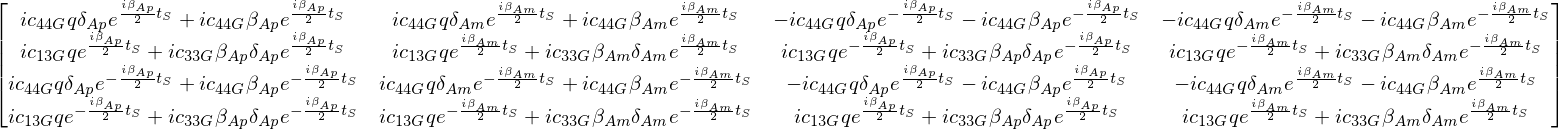

In [437]:
m

In [438]:
l_m_=lambdify((q,w),m.subs(betasubsR).subs(deltasubsR).subs(numerics).subs(tS,6e-9))
l_m=lambda q,w: l_m_(q,w+0j)

In [439]:
l_m

<function __main__.<lambda>(q, w)>

In [440]:
def dm(q,w):
    d=np.linalg.det(l_m(q,w).T)
    

In [441]:
list(enumerate(np.linspace(.1e9,6.26e9,num=25)/1e9))

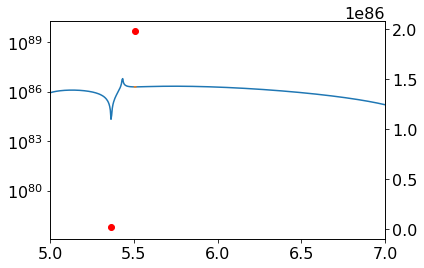

In [442]:
def _inspect():
    q=1.38333333333333333333/nm
    w=e/hbar*np.linspace(.000001e-3,39e-3,10000)

    dw=w[1]-w[0]
    ic=np.abs(np.linalg.det(l_m(q,w).T))
    
    approxroots=[]
    approxroots+=[list(w[1:-1][np.diff(np.sign(np.diff(ic)))==2])]
    
    plt.plot(w/meV,ic)
    for i,ar in enumerate(approxroots[-1]):
        if i!=2: continue
        #if ar<e/hbar*2e-3 or ar>e/hbar*2.5e-3: continue
        res=minimize_scalar(lambda w_: np.abs(np.linalg.det(l_m(q,w_*e/hbar*1e-3).T))/1e18,bracket=np.r_[ar-dw,ar,ar+dw]*hbar/e*1e3,method='brent')
        #print(res.func,"\n")
        #print(hbar/e*res.x*1e3)
        #print("mineig ",np.min(np.abs(np.linalg.eigvals(l_m(q,res.x).T))))
        #print(res,"\n\n")
        wmin=res.x*e/hbar*1e-3
        approxroots[-1][i]=wmin
        w2=np.linspace(ar-dw,ar+dw)
        plt.plot(w2/meV,np.abs(np.linalg.det(l_m(q,w2).T)))
        if(np.abs(np.linalg.det(l_m(q,wmin).T))>np.abs(np.linalg.det(l_m(q,ar).T))):
            print("Minimize scalar failed to do it's job...")
            approxroots[-1][i]=np.NaN
    approxroots[-1]=[ar for ar in approxroots[-1] if not np.isnan(ar)]
    
    plt.yscale('log')
    plt.xlim(5,7)
    plt.twinx()
    for ar in approxroots[-1]:
        plt.plot(ar/meV,np.abs(np.linalg.det(l_m(q,ar))),'ro')
_inspect()

## findmodes

In [443]:
def findmodes(q,wmax,dw,inspect=False,objfuncq=None):
    qs=q
    roots=[]
    
    if inspect:
        # Make plots
        plt.figure()
        ax=plt.gca()
        ax2=plt.twinx()
        
        # Make a color cycler to have a consistent color for each q
        def colorcycler():
            colors=['b','r','g','k','purple']
            i=0;
            while True:
                yield colors[i % len(colors)]
                i+=1
        cc=colorcycler()
    
    # Objective function
    if objfuncq is None:
        objfunc=lambda w: np.abs(np.linalg.det(l_m(q,w).T))
    else:
        objfunc=partial(objfuncq,q)
    
    # For each q separately
    for q in qs:
        print("Solving at q [1/nm]: ", q*nm)
        
        # Evaluate objective on evenly spaced energy grid
        w=np.linspace(dw/1e3,wmax,int(wmax/dw))
        dw=w[1]-w[0]
        fgrid=objfunc(w)
        
        # Plot the gridded values
        if inspect:
            color=next(cc)
            plt.sca(ax)
            plt.plot(w/meV,fgrid,'.-')
        
        # Find all approximate minima captured by the grid,
        # by noting where the sign of the difference changes
        rootsq=list(w[1:-1][np.diff(np.sign(np.diff(fgrid)))==2])
        
        # First, go through and refine the minima
        for i,ar in enumerate(rootsq):
            bracket=np.r_[ar-dw,ar,ar+dw]
            #print(bracket/meV)
            res=minimize_scalar(objfunc,bracket=bracket,method='brent')
            wmin=res.x
            
            #assert (wmin>bracket[0]) and (wmin<bracket[-1])
            
            # Make sure the minimize routine actually lowers the value
            if(res.fun>objfunc(ar)):
                print("Minimize scalar failed to do it's job...")
                rootsq[i]=np.NaN
            else:
                rootsq[i]=wmin
                
        # Remove any "roots" for which minimize failed
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
                
        # Next, check for double roots, minima where the determinant doesn't change sign
        # Note: "sign" in the sense of [1,i,-1,-i]
        # We'll compare the "sign" at a point to the left and a point to the right in between
        # this minima and the nearest adjacent minima
        
        # Note that we're doing this double-root check *before* eliminating spurious minima
        # to make sure that the left and right points inside the "valid" range around the target
        # minima (that is, if we eliminated spurious solutions first, one of the comparison points)
        # might end up having one of those spurious spots in-between it and the target minima
        for i,ar in enumerate(rootsq):
            
            # Nearest minima to left/right, or w-boundary
            left =np.min(w) if i==0             else rootsq[i-1][0]
            right=np.max(w) if i==len(rootsq)-1 else rootsq[i+1]
            
            # Midway between that point and target minima
            left=ar+(left-ar)/2
            right=ar+(right-ar)/2
            
            # Sign to the left
            dl=np.linalg.det(l_m(q,left+0j))
            dl=dl/np.abs(dl)
            
            # Sign to the right
            dr=np.linalg.det(l_m(q,right+0j))
            dr=dr/np.abs(dr)
            
            # If the signs are the same, make it a double root, else single
            if np.isclose(dl,dr,atol=.1):
                rootsq[i]=[ar,ar]
            else:
                rootsq[i]=[ar]
                
        # Reflatten the list
        rootsq=sum(rootsq,[])
            
        
        # Next, elminate spurious solutions
        
        # Second axis for viewing the minimum eigenvalues of "solutions"
        if inspect:
            plt.sca(ax2)
        for i,ar in enumerate(rootsq):
            
            # magnitude of smallest eigenvalue
            mineig=np.min(np.abs(np.linalg.eigvals(l_m(q,ar).T)))
            
            # Make sure the smallest eigenvalue is actually "zero" enough
            if mineig>1e2/nm**2:
                rootsq[i]=np.NaN
            # Make sure the two betas are not actually the same, in which case we don't
            # actually have four independent exponential modes like we thought, so the
            # solution is not a valid one... there may also be solutions of that form, 
            # but we'd have to solve for them separately and they seem too coincidental
            elif np.isclose(l_betaAm(q,ar+0j),l_betaAp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
            # Make sure no beta is zero, because then we don't have four modes
            elif np.abs(l_betaAm(q,ar+0j))<1e-4/nm: #1e-3 works well
                rootsq[i]=np.NaN
            elif np.abs(l_betaAp(q,ar+0j))<1e-4/nm: #1e-3 works well
                rootsq[i]=np.NaN
            
            # Plot the ghost of a mode empty or the real thing filled in
            if inspect:
                if np.isnan(rootsq[i]):
                    plt.plot(ar/meV,mineig,'o',mfc='w',mec=color)
                else:
                    plt.plot(ar/meV,mineig,'o',mfc=color,mec=color)
                
        # Drop the invalid ones from consideration
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
        
        # Add these to a global list for all q's
        roots+=[rootsq]
    
    # Plot styles
    if inspect:
        plt.sca(ax)
        plt.yscale('log')
        plt.sca(ax2)
        plt.yscale('log')
        
    
    # Rectangularize the roots collection
    minnumroots=np.min([len(r) for r in roots])
    print(minnumroots)
    roots=np.array([r[:minnumroots] for r in roots])
    
    return roots

In [132]:
# Run the solution
qs=np.linspace(.1e9,6.26e9,num=25)
approxroots=findmodes(
    q=qs,
    wmax=37*meV,dw=1e-4*meV, inspect=False
)

Solving at q [1/nm]:  0.1
Solving at q [1/nm]:  0.356666666667
Solving at q [1/nm]:  0.613333333333
Solving at q [1/nm]:  0.87
Solving at q [1/nm]:  1.12666666667
Solving at q [1/nm]:  1.38333333333
Solving at q [1/nm]:  1.64
Solving at q [1/nm]:  1.89666666667
Solving at q [1/nm]:  2.15333333333
Solving at q [1/nm]:  2.41
Solving at q [1/nm]:  2.66666666667
Solving at q [1/nm]:  2.92333333333
Solving at q [1/nm]:  3.18
Solving at q [1/nm]:  3.43666666667
Solving at q [1/nm]:  3.69333333333
Solving at q [1/nm]:  3.95
Solving at q [1/nm]:  4.20666666667
Solving at q [1/nm]:  4.46333333333
Solving at q [1/nm]:  4.72
Solving at q [1/nm]:  4.97666666667
Solving at q [1/nm]:  5.23333333333
Solving at q [1/nm]:  5.49
Solving at q [1/nm]:  5.74666666667
Solving at q [1/nm]:  6.00333333333
Solving at q [1/nm]:  6.26
12


Text(0.5,0,'In-plane wavevector [1/nm]')

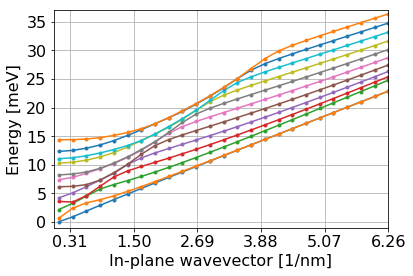

In [133]:
# Plot it
plt.figure()
plt.plot(qs*nm,approxroots/meV,'.-')
plt.ylim(-1,37)
plt.xlim(0,6.26)
plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

In [431]:
# Run the solution
qs=np.linspace(.06e9,.1e9,num=15)
approxroots=findmodes(
    q=qs,
    wmax=1*meV,dw=1e-6*meV, inspect=False
)

Solving at q [1/nm]:  0.06
Solving at q [1/nm]:  0.0628571428571
Solving at q [1/nm]:  0.0657142857143
Solving at q [1/nm]:  0.0685714285714
Solving at q [1/nm]:  0.0714285714286
Solving at q [1/nm]:  0.0742857142857
Solving at q [1/nm]:  0.0771428571429
Solving at q [1/nm]:  0.08
Solving at q [1/nm]:  0.0828571428571
Solving at q [1/nm]:  0.0857142857143
Solving at q [1/nm]:  0.0885714285714
Solving at q [1/nm]:  0.0914285714286
Solving at q [1/nm]:  0.0942857142857
Solving at q [1/nm]:  0.0971428571429
Solving at q [1/nm]:  0.1
1


Text(0.5,0,'In-plane wavevector [1/nm]')

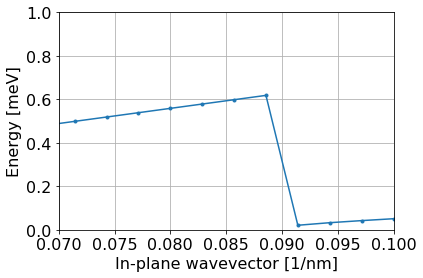

In [149]:
# Plot it
plt.figure()
plt.plot(qs*nm,approxroots/meV,'.-')
plt.ylim(-0,1)
plt.xlim(.07,.1)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

In [453]:
np.linalg.det(l_m(.09/nm,np.r_[.000000000000001*meV]+0j)[:,:,0])

(3.8732702255119249e+74+0j)

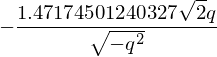

In [484]:
simplify(deltasubsR[deltaAp].subs(w,0).subs(numerics).subs(sqrt(q**4),q**2))#.subs(q,.095/nm)

In [254]:
np.abs(np.linalg.eigvals(l_m(.088/nm,np.r_[.000000000001*meV]+0j)[:,:,0]))

array([  5.40904004e+19,   2.93031243e+19,   2.93031243e+19,
         1.06944580e+16])

Solving at q [1/nm]:  0.088
0


/home/sam/miniconda3/lib/python3.6/site-packages/matplotlib/ticker.py:2198: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  "Data has no positive values, and therefore cannot be "


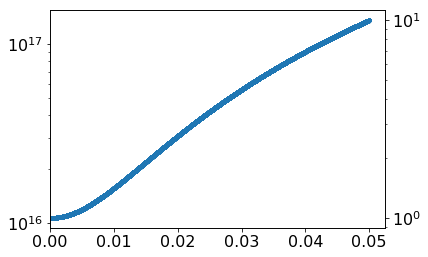

In [248]:
findmodes(
    q=np.r_[.088/nm],
    wmax=.05*meV,dw=1e-6*meV, inspect=True, objfuncq=lambda q,w: np.array([np.min(np.abs(np.linalg.eigvals(l_m(q,np.r_[wi])[:,:,0]))) for wi in w]))/meV
plt.xlim(0)
plt.axhline(0)

In [246]:
np.abs(np.linalg.eigvals(l_m(.1/nm,np.r_[0])[:,:,0]))

array([  6.36947671e+19,   3.51296489e+19,   3.51296489e+19,
         1.33059324e+17])

In [150]:
def _(q,w):
    w=w+0j
    print(w*hbar/e*1e3)
    en,ev=np.linalg.eig(l_m(q,w))
    print(sorted(np.abs(en)))
    coeffs=dict(zip([DApp,DApm,DAmp,DAmm],ev[:,np.argmin(np.abs(en))]))
    print("norm",np.sum(np.abs([v for v in coeffs.values()])**2))
    print(coeffs)
    bsubs={betaAm:l_betaAm(q,w),betaAp:l_betaAp(q,w)}
    dsubs={deltaAm:l_deltaAm(q,w),deltaAp:l_deltaAp(q,w)}
    lux,luz=[lambdify(z,u_alnslab(i).subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
    zn=np.linspace(-3*nm,3*nm)
    plt.figure()
    plt.plot(zn/nm,lux(zn).real,'b')
    plt.plot(zn/nm,lux(zn).imag,'b--')
    plt.plot(zn/nm,luz(zn).real,'g')
    plt.plot(zn/nm,luz(zn).imag,'g--')
    plt.xlim(np.min(zn/nm),np.max(zn/nm))
    plt.ylim(-np.max(np.abs(plt.ylim())),np.min(np.abs(plt.ylim())))
    plt.axvline(0,color='k')
    return lux,luz
lux,luz=_(4.206/nm,approxroots[0,2])

IndexError: index 2 is out of bounds for axis 1 with size 1

# Sandwich

In [432]:
def u_sw(i,r=None):
    if i==x: return\
        DApp*mode.subs(beta, betaAp)+DApm*mode.subs(beta, betaAm)+\
        DAmp*mode.subs(beta,-betaAp)+DAmm*mode.subs(beta,-betaAm)
    if i==y: return 0
    if i==z: return\
        +DApp*deltaAp*mode.subs(beta, betaAp)+DApm*deltaAm*mode.subs(beta, betaAm)+\
        -DAmp*deltaAp*mode.subs(beta,-betaAp)-DAmm*deltaAm*mode.subs(beta,-betaAm)

In [433]:
u=u_alnslab
tS=symbols("{t_S}")

In [434]:
T(u,x,z)

In [435]:
topboundT=[T(u,i,z,mat='GaN').subs(x,0).subs(z,+tS/2) for i in [x,z]]
botboundT=[T(u,i,z,mat='GaN').subs(x,0).subs(z,-tS/2) for i in [x,z]]

In [436]:
m=Matrix([[expand(row).coeff(v) for v in [DApp,DApm,DAmp,DAmm]] for row in topboundT+botboundT])

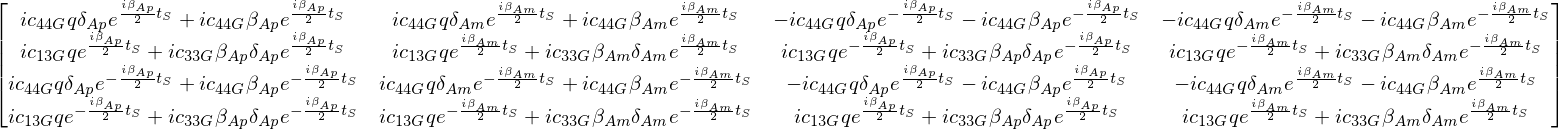

In [437]:
m

In [438]:
l_m_=lambdify((q,w),m.subs(betasubsR).subs(deltasubsR).subs(numerics).subs(tS,6e-9))
l_m=lambda q,w: l_m_(q,w+0j)

In [439]:
l_m

<function __main__.<lambda>(q, w)>

In [440]:
def dm(q,w):
    d=np.linalg.det(l_m(q,w).T)
    

In [441]:
list(enumerate(np.linspace(.1e9,6.26e9,num=25)/1e9))

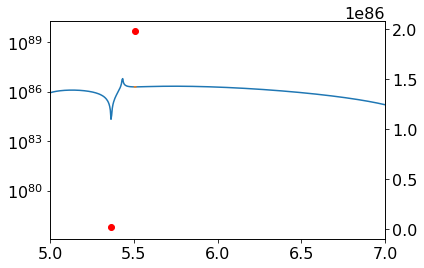

In [442]:
def _inspect():
    q=1.38333333333333333333/nm
    w=e/hbar*np.linspace(.000001e-3,39e-3,10000)

    dw=w[1]-w[0]
    ic=np.abs(np.linalg.det(l_m(q,w).T))
    
    approxroots=[]
    approxroots+=[list(w[1:-1][np.diff(np.sign(np.diff(ic)))==2])]
    
    plt.plot(w/meV,ic)
    for i,ar in enumerate(approxroots[-1]):
        if i!=2: continue
        #if ar<e/hbar*2e-3 or ar>e/hbar*2.5e-3: continue
        res=minimize_scalar(lambda w_: np.abs(np.linalg.det(l_m(q,w_*e/hbar*1e-3).T))/1e18,bracket=np.r_[ar-dw,ar,ar+dw]*hbar/e*1e3,method='brent')
        #print(res.func,"\n")
        #print(hbar/e*res.x*1e3)
        #print("mineig ",np.min(np.abs(np.linalg.eigvals(l_m(q,res.x).T))))
        #print(res,"\n\n")
        wmin=res.x*e/hbar*1e-3
        approxroots[-1][i]=wmin
        w2=np.linspace(ar-dw,ar+dw)
        plt.plot(w2/meV,np.abs(np.linalg.det(l_m(q,w2).T)))
        if(np.abs(np.linalg.det(l_m(q,wmin).T))>np.abs(np.linalg.det(l_m(q,ar).T))):
            print("Minimize scalar failed to do it's job...")
            approxroots[-1][i]=np.NaN
    approxroots[-1]=[ar for ar in approxroots[-1] if not np.isnan(ar)]
    
    plt.yscale('log')
    plt.xlim(5,7)
    plt.twinx()
    for ar in approxroots[-1]:
        plt.plot(ar/meV,np.abs(np.linalg.det(l_m(q,ar))),'ro')
_inspect()

## findmodes

In [443]:
def findmodes(q,wmax,dw,inspect=False,objfuncq=None):
    qs=q
    roots=[]
    
    if inspect:
        # Make plots
        plt.figure()
        ax=plt.gca()
        ax2=plt.twinx()
        
        # Make a color cycler to have a consistent color for each q
        def colorcycler():
            colors=['b','r','g','k','purple']
            i=0;
            while True:
                yield colors[i % len(colors)]
                i+=1
        cc=colorcycler()
    
    # Objective function
    if objfuncq is None:
        objfunc=lambda w: np.abs(np.linalg.det(l_m(q,w).T))
    else:
        objfunc=partial(objfuncq,q)
    
    # For each q separately
    for q in qs:
        print("Solving at q [1/nm]: ", q*nm)
        
        # Evaluate objective on evenly spaced energy grid
        w=np.linspace(dw/1e3,wmax,int(wmax/dw))
        dw=w[1]-w[0]
        fgrid=objfunc(w)
        
        # Plot the gridded values
        if inspect:
            color=next(cc)
            plt.sca(ax)
            plt.plot(w/meV,fgrid,'.-')
        
        # Find all approximate minima captured by the grid,
        # by noting where the sign of the difference changes
        rootsq=list(w[1:-1][np.diff(np.sign(np.diff(fgrid)))==2])
        
        # First, go through and refine the minima
        for i,ar in enumerate(rootsq):
            bracket=np.r_[ar-dw,ar,ar+dw]
            #print(bracket/meV)
            res=minimize_scalar(objfunc,bracket=bracket,method='brent')
            wmin=res.x
            
            #assert (wmin>bracket[0]) and (wmin<bracket[-1])
            
            # Make sure the minimize routine actually lowers the value
            if(res.fun>objfunc(ar)):
                print("Minimize scalar failed to do it's job...")
                rootsq[i]=np.NaN
            else:
                rootsq[i]=wmin
                
        # Remove any "roots" for which minimize failed
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
                
        # Next, check for double roots, minima where the determinant doesn't change sign
        # Note: "sign" in the sense of [1,i,-1,-i]
        # We'll compare the "sign" at a point to the left and a point to the right in between
        # this minima and the nearest adjacent minima
        
        # Note that we're doing this double-root check *before* eliminating spurious minima
        # to make sure that the left and right points inside the "valid" range around the target
        # minima (that is, if we eliminated spurious solutions first, one of the comparison points)
        # might end up having one of those spurious spots in-between it and the target minima
        for i,ar in enumerate(rootsq):
            
            # Nearest minima to left/right, or w-boundary
            left =np.min(w) if i==0             else rootsq[i-1][0]
            right=np.max(w) if i==len(rootsq)-1 else rootsq[i+1]
            
            # Midway between that point and target minima
            left=ar+(left-ar)/2
            right=ar+(right-ar)/2
            
            # Sign to the left
            dl=np.linalg.det(l_m(q,left+0j))
            dl=dl/np.abs(dl)
            
            # Sign to the right
            dr=np.linalg.det(l_m(q,right+0j))
            dr=dr/np.abs(dr)
            
            # If the signs are the same, make it a double root, else single
            if np.isclose(dl,dr,atol=.1):
                rootsq[i]=[ar,ar]
            else:
                rootsq[i]=[ar]
                
        # Reflatten the list
        rootsq=sum(rootsq,[])
            
        
        # Next, elminate spurious solutions
        
        # Second axis for viewing the minimum eigenvalues of "solutions"
        if inspect:
            plt.sca(ax2)
        for i,ar in enumerate(rootsq):
            
            # magnitude of smallest eigenvalue
            mineig=np.min(np.abs(np.linalg.eigvals(l_m(q,ar).T)))
            
            # Make sure the smallest eigenvalue is actually "zero" enough
            if mineig>1e2/nm**2:
                rootsq[i]=np.NaN
            # Make sure the two betas are not actually the same, in which case we don't
            # actually have four independent exponential modes like we thought, so the
            # solution is not a valid one... there may also be solutions of that form, 
            # but we'd have to solve for them separately and they seem too coincidental
            elif np.isclose(l_betaAm(q,ar+0j),l_betaAp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
            # Make sure no beta is zero, because then we don't have four modes
            elif np.abs(l_betaAm(q,ar+0j))<1e-4/nm: #1e-3 works well
                rootsq[i]=np.NaN
            elif np.abs(l_betaAp(q,ar+0j))<1e-4/nm: #1e-3 works well
                rootsq[i]=np.NaN
            
            # Plot the ghost of a mode empty or the real thing filled in
            if inspect:
                if np.isnan(rootsq[i]):
                    plt.plot(ar/meV,mineig,'o',mfc='w',mec=color)
                else:
                    plt.plot(ar/meV,mineig,'o',mfc=color,mec=color)
                
        # Drop the invalid ones from consideration
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
        
        # Add these to a global list for all q's
        roots+=[rootsq]
    
    # Plot styles
    if inspect:
        plt.sca(ax)
        plt.yscale('log')
        plt.sca(ax2)
        plt.yscale('log')
        
    
    # Rectangularize the roots collection
    minnumroots=np.min([len(r) for r in roots])
    print(minnumroots)
    roots=np.array([r[:minnumroots] for r in roots])
    
    return roots

In [132]:
# Run the solution
qs=np.linspace(.1e9,6.26e9,num=25)
approxroots=findmodes(
    q=qs,
    wmax=37*meV,dw=1e-4*meV, inspect=False
)

Solving at q [1/nm]:  0.1
Solving at q [1/nm]:  0.356666666667
Solving at q [1/nm]:  0.613333333333
Solving at q [1/nm]:  0.87
Solving at q [1/nm]:  1.12666666667
Solving at q [1/nm]:  1.38333333333
Solving at q [1/nm]:  1.64
Solving at q [1/nm]:  1.89666666667
Solving at q [1/nm]:  2.15333333333
Solving at q [1/nm]:  2.41
Solving at q [1/nm]:  2.66666666667
Solving at q [1/nm]:  2.92333333333
Solving at q [1/nm]:  3.18
Solving at q [1/nm]:  3.43666666667
Solving at q [1/nm]:  3.69333333333
Solving at q [1/nm]:  3.95
Solving at q [1/nm]:  4.20666666667
Solving at q [1/nm]:  4.46333333333
Solving at q [1/nm]:  4.72
Solving at q [1/nm]:  4.97666666667
Solving at q [1/nm]:  5.23333333333
Solving at q [1/nm]:  5.49
Solving at q [1/nm]:  5.74666666667
Solving at q [1/nm]:  6.00333333333
Solving at q [1/nm]:  6.26
12


Text(0.5,0,'In-plane wavevector [1/nm]')

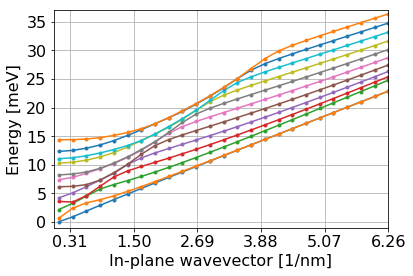

In [133]:
# Plot it
plt.figure()
plt.plot(qs*nm,approxroots/meV,'.-')
plt.ylim(-1,37)
plt.xlim(0,6.26)
plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

# pFET

In [157]:
def u_pfet(i,r=None):
    if r=='well':
        if i==x: return\
            DGpp*mode.subs(beta, betaGp)+DGpm*mode.subs(beta, betaGm)+\
            DGmp*mode.subs(beta,-betaGp)+DGmm*mode.subs(beta,-betaGm)
        if i==y: return 0
        if i==z: return\
            +DGpp*deltaGp*mode.subs(beta, betaGp)+DGpm*deltaGm*mode.subs(beta, betaGm)+\
            -DGmp*deltaGp*mode.subs(beta,-betaGp)-DGmm*deltaGm*mode.subs(beta,-betaGm)
        
    elif r=='buff':
        if i==x: return\
            DApp*mode.subs(beta, betaAp)+DApm*mode.subs(beta, betaAm)
        if i==y: return 0
        if i==z: return\
            +DApp*deltaAp*mode.subs(beta, betaAp)+DApm*deltaAm*mode.subs(beta, betaAm)
    else:
        raise Exception("Unknown region "+str(r))

In [158]:
u=u_pfet
tW=symbols("{t_W}")

In [159]:
topboundT=[T(u,i,z,mat='GaN',r='well').subs(x,0).subs(z,-tW) for i in [x,z]]
intboundT=[T(u,i,z,mat='GaN',r='well').subs(x,0).subs(z,0)-T(u,i,z,mat='AlN',r='buff').subs(x,0).subs(z,0) for i in [x,z]]
intboundu=[ (100*GPa/nm)*u(i,r='well').subs(x,0).subs(z,0)- (100*GPa/nm)*u(i,r='buff').subs(x,0).subs(z,0) for i in [x,z]]

In [160]:
u_pfet(x,r='well').subs({betaGm:0,betaGp:0,x:0})

In [161]:
m=Matrix([[expand(row).coeff(v) for v in [DGpp,DGpm,DGmp,DGmm,DApp,DApm]] for row in topboundT+intboundT+intboundu])

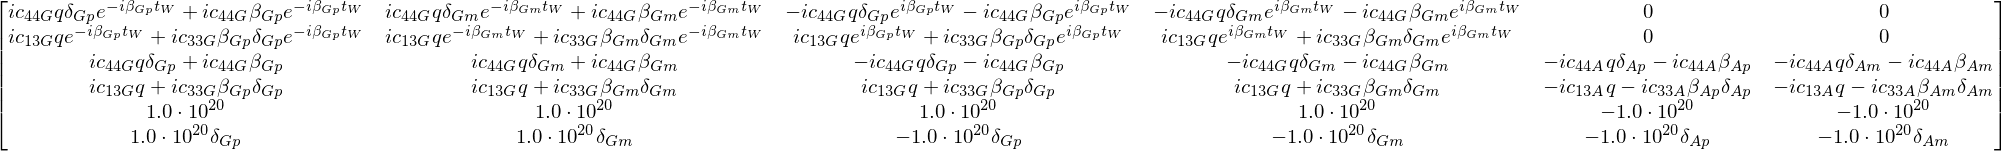

In [162]:
m

In [163]:
simplify(m[0,:]/(I*c44G))

In [164]:
simplify(m[1,:]/(I))

In [165]:
m.shape

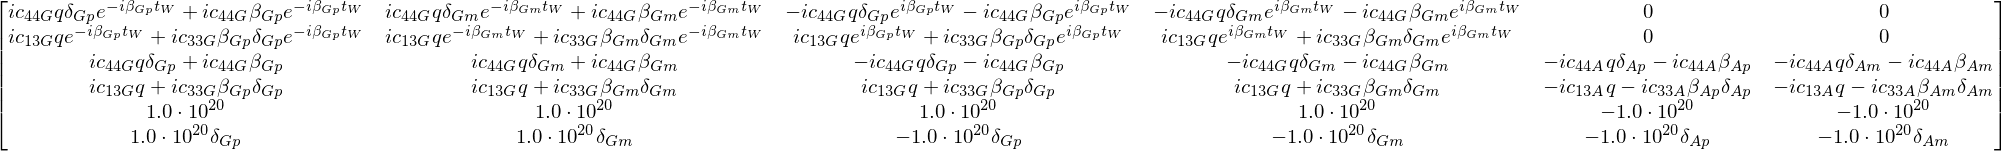

In [166]:
m#+Matrix([[1]*6]*6)*w

In [167]:
numerics[c13G]/nm

In [168]:
1/nm

In [169]:
def _():
    w=np.array([1,2,3])
    return (np.ones([6,6]+list(w.shape))*w)
_()[0,0]
    

array([ 1.,  2.,  3.])

In [170]:
l_m_=lambdify((q,w),(m+Matrix([[1]*6]*6)*w/meV).subs(betasubsR).subs(deltasubsR).subs(numerics).subs(tW,10e-9))
l_m=lambda q,w: l_m_(q,w+0j)-np.ones([6,6]+list(w.shape))*w/meV

In [171]:
l_m(.5/nm,np.r_[.5*meV])

array([[[ -3.24342590e+21 +0.00000000e+00j],
        [ -2.34746780e+23 +0.00000000e+00j],
        [  9.52293922e+18 +0.00000000e+00j],
        [  4.36354117e+16 +0.00000000e+00j],
        [  2.22044605e-16 +0.00000000e+00j],
        [  2.22044605e-16 +0.00000000e+00j]],

       [[  2.22044605e-16 -4.94163818e+21j],
        [  2.22044605e-16 -1.47452685e+23j],
        [  2.22044605e-16 -1.45090165e+19j],
        [  2.22044605e-16 -2.74089324e+16j],
        [  2.22044605e-16 +0.00000000e+00j],
        [  2.22044605e-16 +0.00000000e+00j]],

       [[ -1.75746828e+20 +0.00000000e+00j],
        [ -1.01209053e+20 +0.00000000e+00j],
        [  1.75746828e+20 +0.00000000e+00j],
        [  1.01209053e+20 +0.00000000e+00j],
        [  1.63373755e+20 +0.00000000e+00j],
        [  1.10745805e+20 +0.00000000e+00j]],

       [[  2.22044605e-16 -2.67765401e+20j],
        [  2.22044605e-16 -6.35729556e+19j],
        [  2.22044605e-16 -2.67765401e+20j],
        [  2.22044605e-16 -6.35729556e+19j],
    

## findmodes

In [172]:
def findmodes(q,dw,inspect=False):
    qs=q
    roots=[]
    
    if inspect:
        # Make plots
        plt.figure(figsize=(10,5))
        ax=plt.subplot(121)
        ax2=plt.twinx()
        axs=plt.subplot(122)
        
        # Make a color cycler to have a consistent color for each q
        def colorcycler():
            colors=['b','r','g','k','purple']
            i=0;
            while True:
                yield colors[i % len(colors)]
                i+=1
        cc=colorcycler()
    
    # Objective function
    objfunc=lambda w: np.abs(np.linalg.det(l_m(q,w).T))
    
    # For each q separately
    for q in qs:
        print("Solving at q [1/nm]: ", q*nm)
        
        # Evaluate objective on evenly spaced energy grid
        wmax=float(sqrt(c44A/pA).subs(numerics)*q)
        #w=np.linspace(dw/1e3,wmax-dw/1e3,int(wmax/dw))
        w=np.linspace(dw/1e3,wmax*1.5,int(1.5*wmax/dw))
        dw=w[1]-w[0]
        print("  dw: ",dw/meV, " meV")
        fgrid=objfunc(w)
        
        # Plot the gridded values
        if inspect:
            color=next(cc)
            plt.sca(ax)
            plt.plot(w/meV,fgrid,'.-')
        
        # Find all approximate minima captured by the grid,
        # by noting where the sign of the difference changes
        rootsq=list(w[1:-1][np.diff(np.sign(np.diff(fgrid)))==2])
        
        # First, go through and refine the minima
        for i,ar in enumerate(rootsq):
            bracket=np.r_[ar-dw,ar,ar+dw]
            #print(bracket/meV)
            res=minimize_scalar(objfunc,bracket=bracket,method='brent')
            wmin=res.x
            
            #assert (wmin>bracket[0]) and (wmin<bracket[-1])
            
            # Make sure the minimize routine actually lowers the value
            if(res.fun>objfunc(ar)):
                print("Minimize scalar failed to do it's job...")
                rootsq[i]=np.NaN
            else:
                rootsq[i]=wmin
                
        # Remove any "roots" for which minimize failed
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
                
        # Next, check for double roots, minima where the determinant doesn't change sign
        # Note: "sign" in the sense of [1,i,-1,-i]
        # We'll compare the "sign" at a point to the left and a point to the right in between
        # this minima and the nearest adjacent minima
        
        # Note that we're doing this double-root check *before* eliminating spurious minima
        # to make sure that the left and right points inside the "valid" range around the target
        # minima (that is, if we eliminated spurious solutions first, one of the comparison points)
        # might end up having one of those spurious spots in-between it and the target minima
        for i,ar in enumerate(rootsq):
            
            # Nearest minima to left/right, or w-boundary
            left =np.min(w) if i==0             else rootsq[i-1][0]
            right=np.max(w) if i==len(rootsq)-1 else rootsq[i+1]
            
            # Midway between that point and target minima
            left=ar+(left-ar)/2
            right=ar+(right-ar)/2
            
            # Sign to the left
            dl=np.linalg.det(l_m(q,left+0j))
            dl=dl/np.abs(dl)
            
            # Sign to the right
            dr=np.linalg.det(l_m(q,right+0j))
            dr=dr/np.abs(dr)
            
            # If the signs are the same, make it a double root, else single
            if np.isclose(dl,dr,atol=.1):
                rootsq[i]=[ar,ar]
            else:
                rootsq[i]=[ar]
                
        # Reflatten the list
        rootsq=sum(rootsq,[])
            
        
        # Next, elminate spurious solutions
        
        # Second axis for viewing the minimum eigenvalues of "solutions"
        if inspect:
            plt.sca(ax2)
        for i,ar in enumerate(rootsq):
            
            # magnitude of smallest eigenvalue
            mineig=np.min(np.abs(np.linalg.eigvals(l_m(q,ar).T)))
            
            # Make sure the smallest eigenvalue is actually "zero" enough
            if mineig>1e-2/nm**2:
                rootsq[i]=np.NaN
            # Make sure the two betas are not actually the same, in which case we don't
            # actually have four independent exponential modes like we thought, so the
            # solution is not a valid one... there may also be solutions of that form, 
            # but we'd have to solve for them separately and they seem too coincidental
            elif np.isclose(l_betaAm(q,ar+0j),l_betaAp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
            elif np.isclose(l_betaGm(q,ar+0j),l_betaGp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
            # Make sure no beta is zero, because then we don't have four modes
            #elif np.abs(l_betaAm(q,ar+0j))<1e-3/nm:
            #    rootsq[i]=np.NaN
            #elif np.abs(l_betaAp(q,ar+0j))<1e-3/nm:
            #    rootsq[i]=np.NaN
            elif np.abs(l_betaGm(q,ar+0j))<1e-3/nm:
                rootsq[i]=np.NaN
            elif np.abs(l_betaGp(q,ar+0j))<1e-3/nm:
                rootsq[i]=np.NaN
            
            # Plot the ghost of a mode empty or the real thing filled in
            if inspect:
                if np.isnan(rootsq[i]):
                    plt.plot(ar/meV,mineig,'o',mfc='w',mec=color)
                else:
                    plt.plot(ar/meV,mineig,'o',mfc=color,mec=color)
                
        # Drop the invalid ones from consideration
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
        
        # Add these to a global list for all q's
        roots+=[rootsq]
    
    # Plot styles
    if inspect:
        plt.sca(ax)
        plt.yscale('log')
        plt.sca(ax2)
        plt.yscale('log')
        plt.tight_layout()
        ####
        #plt.xlim(wmax/meV-.01,wmax/meV+.01)
        plt.axvline(wmax/meV,color='k')
    
    # Rectangularize the roots collection
    
    minnumroots=np.min([len(r) for r in roots])
    maxnumroots=np.max([len(r) for r in roots])
    roots=np.array([(list(r)+[np.NaN]*(maxnumroots-minnumroots))[:maxnumroots] for r in roots])
    
    solns=[]
    for q,rs in zip(qs, roots):
        sols=[]
        solns+=[sols]
        for r in rs:
            if np.isnan(r):
                sols+=[None]
            else:
                w=r+0j
                en,ev=np.linalg.eig(l_m(q,np.r_[w])[:,:,0])
                coeffs=dict(zip([DGpp,DGpm,DGmp,DGmm,DApp,DApm],ev[:,np.argmin(np.abs(en))]))
                bsubs={betaAm:l_betaAm(q,w),betaAp:l_betaAp(q,w),betaGm:l_betaGm(q,w),betaGp:l_betaGp(q,w)}
                dsubs={deltaAm:l_deltaAm(q,w),deltaAp:l_deltaAp(q,w),deltaGm:l_deltaGm(q,w),deltaGp:l_deltaGp(q,w)}
                lux_w,luz_w=[lambdify(z,u_pfet(i,r='well').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
                lux_b,luz_b=[lambdify(z,u_pfet(i,r='buff').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
                def lu(z,i,lux_w=lux_w,luz_w=luz_w,lux_b=lux_b,luz_b=luz_b):
                    return (z<0)*(i==x)*lux_w + (z<0)*(i==z)*luz_w +(z>=0)*(i==x)*lux_b + (z>=0)*(i==z)*luz_b
                sols+=[{
                    'coeffs':coeffs,
                    'bsubs': bsubs,
                    'dsubs': dsubs,
                    'lu': lu
                }]
                
    if inspect:
        for q in qs:
            print(roots)
            if hasattr(inspect,'__iter__'): inspect=inspect[0]
            else: inspect=0
            if inspect>len(roots[0])-1: return roots
            w=roots[0][inspect]+0j
            plt.sca(axs)
            print(type(q),type(w))
            print(q,w,l_m(q,w).shape)
            en,ev=np.linalg.eig(l_m(q,np.r_[w])[:,:,0])
            print(sorted(np.abs(en)))
            coeffs=dict(zip([DGpp,DGpm,DGmp,DGmm,DApp,DApm],ev[:,np.argmin(np.abs(en))]))
            print("norm",np.sum(np.abs([v for v in coeffs.values()])**2))
            print(coeffs)

            bsubs={betaAm:l_betaAm(q,w),betaAp:l_betaAp(q,w),betaGm:l_betaGm(q,w),betaGp:l_betaGp(q,w)}
            dsubs={deltaAm:l_deltaAm(q,w),deltaAp:l_deltaAp(q,w),deltaGm:l_deltaGm(q,w),deltaGp:l_deltaGp(q,w)}
            print("\n\n\nHI\n\n")
            #print(u_pfet(x,r='well').subs({betaGm:0,betaGp:0,x:0}))
            display({k:v*nm for k,v in bsubs.items()})
            display({k:v for k,v in dsubs.items()})
            #print(u_pfet(x,r='well').subs(dsubs).subs({betaGp:l_betaGp(q,w)[0]}))
            lux_w,luz_w=[lambdify(z,u_pfet(i,r='well').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
            lux_b,luz_b=[lambdify(z,u_pfet(i,r='buff').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]

            
            zn=np.linspace(-10*nm,0*nm)
            plt.plot(zn/nm,lux_w(zn).real,'b')
            plt.plot(zn/nm,lux_w(zn).imag,'b--')
            plt.plot(zn/nm,luz_w(zn).real,'g')
            plt.plot(zn/nm,luz_w(zn).imag,'g--')
            zn=np.linspace(0*nm,30*nm)
            plt.plot(zn/nm,lux_b(zn).real,'b')
            plt.plot(zn/nm,lux_b(zn).imag,'b--')
            plt.plot(zn/nm,luz_b(zn).real,'g')
            plt.plot(zn/nm,luz_b(zn).imag,'g--')
            plt.axvline(0,color='k')
            
            plt.xlim(-10,np.max(zn/nm))
            #plt.ylim(-1,10)
            #plt.ylim(-np.max(np.abs(plt.ylim())),np.min(np.abs(plt.ylim())))
    return roots,solns

In [173]:
# Run the solution
qs=np.linspace(.01e9,2e9,num=200)
approxroots,approxsolns=findmodes(
    q=qs,dw=1e-4*meV, inspect=False
)

Solving at q [1/nm]:  0.01
  dw:  0.000100331748002  meV
Solving at q [1/nm]:  0.02
  dw:  0.000100417367283  meV
Solving at q [1/nm]:  0.03
  dw:  0.000100503076117  meV
Solving at q [1/nm]:  0.04
  dw:  0.000100545985406  meV
Solving at q [1/nm]:  0.05
  dw:  0.000100606108589  meV
Solving at q [1/nm]:  0.06
  dw:  0.000100646230663  meV
Solving at q [1/nm]:  0.07
  dw:  0.000100674908888  meV
Solving at q [1/nm]:  0.08
  dw:  0.000100696428285  meV
Solving at q [1/nm]:  0.09
  dw:  0.000100732311668  meV
Solving at q [1/nm]:  0.1
  dw:  0.00010076103679  meV
Solving at q [1/nm]:  0.11
  dw:  0.000100784551352  meV
Solving at q [1/nm]:  0.12
  dw:  0.000100804155205  meV
Solving at q [1/nm]:  0.13
  dw:  0.000100820749039  meV
Solving at q [1/nm]:  0.14
  dw:  0.000100834976674  meV
Solving at q [1/nm]:  0.15
  dw:  0.000100847310539  meV
Solving at q [1/nm]:  0.16
  dw:  0.000100858105147  meV
Solving at q [1/nm]:  0.17
  dw:  0.000100877794706  meV
Solving at q [1/nm]:  0.18
  dw: 

Solving at q [1/nm]:  1.46
  dw:  0.000101412281851  meV
Solving at q [1/nm]:  1.47
  dw:  0.00010141435669  meV
Solving at q [1/nm]:  1.48
  dw:  0.000101416403575  meV
Solving at q [1/nm]:  1.49
  dw:  0.000101418423065  meV
Solving at q [1/nm]:  1.5
  dw:  0.000101420415707  meV
Solving at q [1/nm]:  1.51
  dw:  0.000101422382034  meV
Solving at q [1/nm]:  1.52
  dw:  0.000101424322562  meV
Solving at q [1/nm]:  1.53
  dw:  0.000101426237797  meV
Solving at q [1/nm]:  1.54
  dw:  0.00010142812823  meV
Solving at q [1/nm]:  1.55
  dw:  0.000101429994339  meV
Solving at q [1/nm]:  1.56
  dw:  0.000101431836592  meV
Solving at q [1/nm]:  1.57
  dw:  0.000101433655441  meV
Solving at q [1/nm]:  1.58
  dw:  0.000101435451331  meV
Solving at q [1/nm]:  1.59
  dw:  0.000101437224694  meV
Solving at q [1/nm]:  1.6
  dw:  0.000101438975951  meV
Solving at q [1/nm]:  1.61
  dw:  0.000101440705512  meV
Solving at q [1/nm]:  1.62
  dw:  0.000101442413778  meV
Solving at q [1/nm]:  1.63
  dw:  0

Text(0.5,0,'In-plane wavevector [1/nm]')

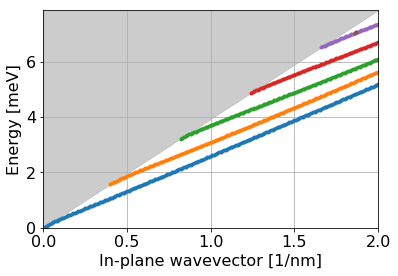

In [174]:
# Plot it
plt.figure()
v1=float(sqrt(c44A/pA).subs(numerics))
plt.fill_betweenx(v1*qs/meV,qs*nm,linewidth=.5,color='k',alpha=.2)
plt.plot(qs*nm,approxroots/meV,'.-')

#plt.text(1,4,"Continuum",rotation=np.arc)

#v2=float(sqrt(c44G/pG).subs(numerics))
#plt.plot(qs*nm,v2*qs/meV,linewidth=.5,color='k')

plt.xlim(0,qs[-1]*nm)
plt.ylim(0,v1*qs[-1]/meV)
#plt.ylim(-1,37)
#plt.xlim(0,6.26)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

In [181]:
qs[100]*nm

In [183]:
approxsolns[100][2]

{'coeffs': {{D^{+}_{+1G}}: (-0.3692772250646249-0.34092744586468926j),
  {D^{+}_{-1G}}: (-1.1569023632721868e-05+2.958593336735157e-05j),
  {D^{-}_{+1G}}: (0.50259048886361535+0j),
  {D^{-}_{-1G}}: (-0.13521859656605087+0.34580003486737743j),
  {D^{+}_{+1A}}: (0.15288929328849801-0.39099001104037745j),
  {D^{+}_{-1A}}: (-0.15480621594559657+0.39589213808414403j)},
 'bsubs': {{\beta_{Am}}: 1168534879.48879j,
  {\beta_{Ap}}: 264635897.83220229j,
  {\beta_{Gm}}: 1010684088.7734851j,
  {\beta_{Gp}}: (650651105.36603653+0j)},
 'dsubs': {{\delta_{Am}}: 0.53353600337279239j,
  {\delta_{Ap}}: 4.865806238401591j,
  {\delta_{Gm}}: 0.43371818801987044j,
  {\delta_{Gp}}: (-1.7678048486254792+0j)},
 'lu': <function __main__.findmodes.<locals>.lu(z, i, lux_w=<function <lambda> at 0x7f30c900fb70>, luz_w=<function <lambda> at 0x7f30c900f620>, lux_b=<function <lambda> at 0x7f30c900f730>, luz_b=<function <lambda> at 0x7f30c900fbf8>)>}

In [802]:
(qs[1]-qs[0])/1e9

In [803]:
np.diff([0]+[qs[np.argmin(np.isnan(approxroots[:,i]))] for i in range(1,5)])*nm

array([ 0.4 ,  0.42,  0.42,  0.42])

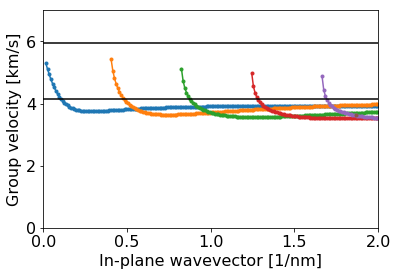

In [804]:
plt.plot((qs[1:]+qs[:-1])*nm/2,(np.diff(approxroots,axis=0).T/np.diff(qs)).T/1e3,'.-')
plt.ylabel("Group velocity [km/s]")
plt.xlabel("In-plane wavevector [1/nm]")
plt.ylim(0,7)
plt.xlim(0,qs[-1]*nm)
plt.axhline(float(sqrt(c44A/pA).subs(numerics))/1e3,color='k')
plt.axhline(float(sqrt(c44G/pG).subs(numerics))/1e3,color='k')

# pFET continuum

In [99]:
def u_pfet(i,r=None):
    if r=='well':
        if i==x: return\
            DGpp*mode.subs(beta, betaGp)+DGpm*mode.subs(beta, betaGm)+\
            DGmp*mode.subs(beta,-betaGp)+DGmm*mode.subs(beta,-betaGm)
        if i==y: return 0
        if i==z: return\
            +DGpp*deltaGp*mode.subs(beta, betaGp)+DGpm*deltaGm*mode.subs(beta, betaGm)+\
            -DGmp*deltaGp*mode.subs(beta,-betaGp)-DGmm*deltaGm*mode.subs(beta,-betaGm)
        
    elif r=='buff':
        if i==x: return\
            DApp*mode.subs(beta, betaAp)+DApm*mode.subs(beta, betaAm)+\
            DAmp*mode.subs(beta,-betaAp)+DAmm*mode.subs(beta,-betaAm)
        if i==y: return 0
        if i==z: return\
            +DApp*deltaAp*mode.subs(beta, betaAp)+DApm*deltaAm*mode.subs(beta, betaAm)+\
            -DAmp*deltaAp*mode.subs(beta,-betaAp)-DAmm*deltaAm*mode.subs(beta,-betaAm)
    else:
        raise Exception("Unknown region "+str(r))

In [100]:
u=u_pfet
tW,tB=symbols("{t_W},{t_B}")

In [101]:
topboundT=[T(u,i,z,mat='GaN',r='well').subs(x,0).subs(z,-tW) for i in [x,z]]
intboundT=[T(u,i,z,mat='GaN',r='well').subs(x,0).subs(z,0)-T(u,i,z,mat='AlN',r='buff').subs(x,0).subs(z,0) for i in [x,z]]
intboundu=[ (100*GPa/nm)*u(i,r='well').subs(x,0).subs(z,0)- (100*GPa/nm)*u(i,r='buff').subs(x,0).subs(z,0) for i in [x,z]]
botboundu=[ (100*GPa/nm)*u(i,r='buff').subs(x,0).subs(z, tB) for i in [x,z]]


In [102]:
m=Matrix([[expand(row).coeff(v) for v in [DGpp,DGpm,DGmp,DGmm,DApp,DApm,DAmp,DAmm]] for row in topboundT+intboundT+intboundu+botboundu])

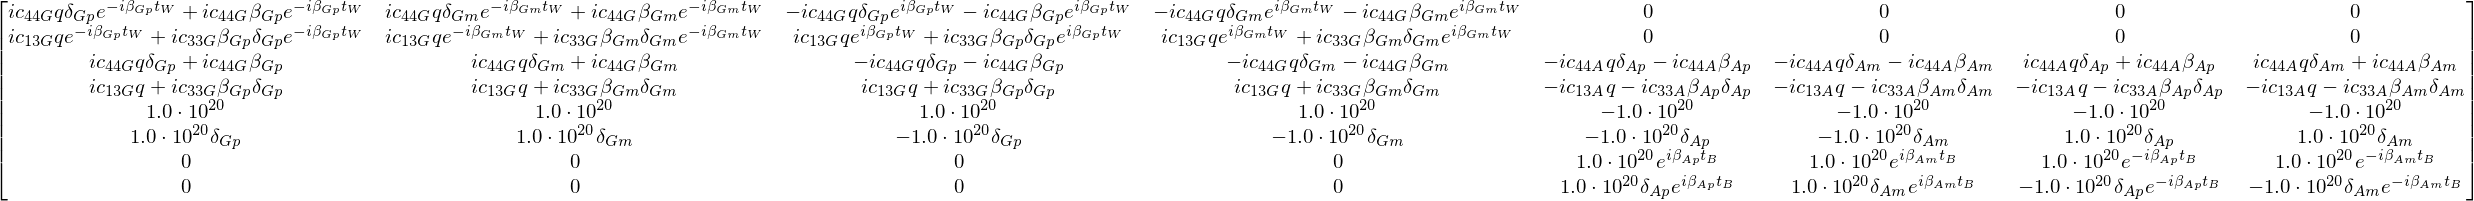

In [103]:
m

In [136]:
l_m_=lambdify((q,w),(m+Matrix([[1]*8]*8)*w/meV).subs(betasubsR).subs(deltasubsR).subs(numerics).subs(tW,10e-9).subs(tB,40e-9))
l_m=lambda q,w: l_m_(q,w+0j)-np.ones([8,8]+list(w.shape))*w/meV

In [135]:
l_m(.7/nm,np.r_[1.8*meV+0j])

array([[[ -2.18665205e+21 +0.00000000e+00j],
        [ -1.29085258e+24 +0.00000000e+00j],
        [  1.10652524e+20 +0.00000000e+00j],
        [  1.24810751e+16 +0.00000000e+00j],
        [  8.88178420e-16 +0.00000000e+00j],
        [  8.88178420e-16 +0.00000000e+00j],
        [  8.88178420e-16 +0.00000000e+00j],
        [  8.88178420e-16 +0.00000000e+00j]],

       [[  8.88178420e-16 -1.38036434e+21j],
        [  8.88178420e-16 -7.72067040e+23j],
        [  8.88178420e-16 -6.98514416e+19j],
        [  8.88178420e-16 -7.46500949e+15j],
        [  8.88178420e-16 +0.00000000e+00j],
        [  8.88178420e-16 +0.00000000e+00j],
        [  8.88178420e-16 +0.00000000e+00j],
        [  8.88178420e-16 +0.00000000e+00j]],

       [[ -4.91892843e+20 +0.00000000e+00j],
        [ -1.26930012e+20 +0.00000000e+00j],
        [  4.91892843e+20 +0.00000000e+00j],
        [  1.26930012e+20 +0.00000000e+00j],
        [  2.45967401e+20 +0.00000000e+00j],
        [  1.47458436e+20 +0.00000000e+00j],
      

## findmodes

In [150]:
def findmodes(q,wmax,dw,inspect=False):
    qs=q
    roots=[]
    
    if inspect:
        # Make plots
        plt.figure(figsize=(10,5))
        ax=plt.subplot(121)
        ax2=plt.twinx()
        axs=plt.subplot(122)
        
        # Make a color cycler to have a consistent color for each q
        def colorcycler():
            colors=['b','r','g','k','purple']
            i=0;
            while True:
                yield colors[i % len(colors)]
                i+=1
        cc=colorcycler()
    
    # Objective function
    objfunc=lambda w: np.abs(np.linalg.det(l_m(q,w).T))
    
    # For each q separately
    for q in qs:
        print("Solving at q [1/nm]: ", q*nm)
        
        # Evaluate objective on evenly spaced energy grid
        #wmax=float(sqrt(c44A/pA).subs(numerics)*q)
        #w=np.linspace(dw/1e3,wmax-dw/1e3,int(wmax/dw))
        w=np.linspace(dw/1e3,wmax,int(wmax/dw))
        dw=w[1]-w[0]
        #print("  dw: ",dw/meV, " meV")
        fgrid=objfunc(w)
        
        # Plot the gridded values
        if inspect:
            color=next(cc)
            plt.sca(ax)
            plt.plot(w/meV,fgrid,'.-')
            plt.yscale('log')
        
        # Find indices of all approximate minima captured by the grid,
        # by noting where the sign of the difference changes
        rootsqi=np.arange(1,len(w)-1)[list(np.diff(np.sign(np.diff(fgrid)))==2)]
        rootsq=[np.NaN]*len(rootsqi)
        print("  ",len(rootsq)," potential roots to examine")
        
        # First, go through and refine the minima
        for i,iw in enumerate(rootsqi):
            bracket=w[iw-1:iw+2]
            ar=w[iw]
            #try:
            res=minimize_scalar(objfunc,bracket=bracket,method='brent')
            #except:
            #    print("Bracketed values: ",objfunc(bracket))
            #    # If minimize_scalar fails, show a zoom in on this point
            #    if inspect:
            #        plt.plot(ar/meV,objfunc(ar),'ro')
            #        plt.xlim((ar-10*dw)/meV,(ar+10*dw)/meV)
            #    raise
            wmin=res.x
            
            #assert (wmin>bracket[0]) and (wmin<bracket[-1])
            
            # Make sure the minimize routine actually lowers the value
            print("brent imprv ",res.fun/objfunc(ar))
            if(res.fun>objfunc(ar)):
                print("Minimize scalar failed to do it's job...")
            else:
                rootsq[i]=wmin
                
        # Remove any "roots" for which minimize failed
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
                
        # Next, check for double roots, minima where the determinant doesn't change sign
        # Note: "sign" in the sense of [1,i,-1,-i]
        # We'll compare the "sign" at a point to the left and a point to the right in between
        # this minima and the nearest adjacent minima
        
        # Note that we're doing this double-root check *before* eliminating spurious minima
        # to make sure that the left and right points inside the "valid" range around the target
        # minima (that is, if we eliminated spurious solutions first, one of the comparison points)
        # might end up having one of those spurious spots in-between it and the target minima
        for i,ar in enumerate(rootsq):
            
            # Nearest minima to left/right, or w-boundary
            left =np.min(w) if i==0             else rootsq[i-1][0]
            right=np.max(w) if i==len(rootsq)-1 else rootsq[i+1]
            
            # Midway between that point and target minima
            left=ar+(left-ar)/2
            right=ar+(right-ar)/2
            
            # Sign to the left
            dl=np.linalg.det(l_m(q,left+0j))
            dl=dl/np.abs(dl)
            
            # Sign to the right
            dr=np.linalg.det(l_m(q,right+0j))
            dr=dr/np.abs(dr)
            
            # If the signs are the same, make it a double root, else single
            if np.isclose(dl,dr,atol=.1):
                rootsq[i]=[ar,ar]
            else:
                rootsq[i]=[ar]
                
        # Reflatten the list
        rootsq=sum(rootsq,[])
            
        
        # Next, elminate spurious solutions
        
        # Second axis for viewing the minimum eigenvalues of "solutions"
        if inspect:
            plt.sca(ax2)
        for i,ar in enumerate(rootsq):
            
            # magnitude of smallest eigenvalue
            mineig=np.min(np.abs(np.linalg.eigvals(l_m(q,ar).T)))
            
            # Make sure the smallest eigenvalue is actually "zero" enough
            if mineig>1e-2/nm**2:  #actually use 1e-2/nm**2:
                rootsq[i]=np.NaN
            # Make sure the two betas are not actually the same, in which case we don't
            # actually have four independent exponential modes like we thought, so the
            # solution is not a valid one... there may also be solutions of that form, 
            # but we'd have to solve for them separately and they seem too coincidental
            elif np.isclose(l_betaAm(q,ar+0j),l_betaAp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
            elif np.isclose(l_betaGm(q,ar+0j),l_betaGp(q,ar+0j),atol=1e-3/nm):
                rootsq[i]=np.NaN
            # Make sure no beta is zero, because then we don't have four modes
            #elif np.abs(l_betaAm(q,ar+0j))<1e-3/nm:
            #    rootsq[i]=np.NaN
            #elif np.abs(l_betaAp(q,ar+0j))<1e-3/nm:
            #    rootsq[i]=np.NaN
            elif np.abs(l_betaGm(q,ar+0j))<1e-3/nm:
                rootsq[i]=np.NaN
            elif np.abs(l_betaGp(q,ar+0j))<1e-3/nm:
                rootsq[i]=np.NaN
            
            # Plot the ghost of a mode empty or the real thing filled in
            if inspect:
                if np.isnan(rootsq[i]):
                    plt.plot(ar/meV,mineig,'o',mfc='w',mec=color)
                else:
                    plt.plot(ar/meV,mineig,'o',mfc=color,mec=color)
                
        # Drop the invalid ones from consideration
        rootsq=[ar for ar in rootsq if not np.isnan(ar)]
        
        # Add these to a global list for all q's
        roots+=[rootsq]
    
    # Plot styles
    if inspect:
        plt.sca(ax)
        plt.yscale('log')
        plt.sca(ax2)
        plt.yscale('log')
        plt.tight_layout()
        ####
        #plt.xlim(wmax/meV-.01,wmax/meV+.01)
        #plt.xlim(.75,.85)
        plt.axvline(wmax/meV,color='k')
    
    # Rectangularize the roots collection
    
    minnumroots=np.min([len(r) for r in roots])
    maxnumroots=np.max([len(r) for r in roots])
    roots=np.array([(list(r)+[np.NaN]*(maxnumroots-minnumroots))[:maxnumroots] for r in roots])
    
    solns=[]
    for q,rs in zip(qs, roots):
        sols=[]
        solns+=[sols]
        for r in rs:
            if np.isnan(r):
                sols+=[None]
            else:
                w=r+0j
                en,ev=np.linalg.eig(l_m(q,np.r_[w])[:,:,0])
                coeffs=dict(zip([DGpp,DGpm,DGmp,DGmm,DApp,DApm,DAmp,DAmm],ev[:,np.argmin(np.abs(en))]))
                bsubs={betaAm:l_betaAm(q,w),betaAp:l_betaAp(q,w),betaGm:l_betaGm(q,w),betaGp:l_betaGp(q,w)}
                dsubs={deltaAm:l_deltaAm(q,w),deltaAp:l_deltaAp(q,w),deltaGm:l_deltaGm(q,w),deltaGp:l_deltaGp(q,w)}
                lux_w,luz_w=[lambdify(z,u_pfet(i,r='well').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
                lux_b,luz_b=[lambdify(z,u_pfet(i,r='buff').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
                def lu(z,i,lux_w=lux_w,luz_w=luz_w,lux_b=lux_b,luz_b=luz_b):
                    return (z<0)*(i==x)*lux_w + (z<0)*(i==z)*luz_w +(z>=0)*(i==x)*lux_b + (z>=0)*(i==z)*luz_b
                sols+=[{
                    'coeffs':coeffs,
                    'bsubs': bsubs,
                    'dsubs': dsubs,
                    'lu': lu
                }]
                
    if inspect:
        for q in qs:
            print(roots)
            if hasattr(inspect,'__iter__'): inspect=inspect[0]
            else: inspect=0
            if inspect>len(roots[0])-1: return roots,solns
            w=roots[0][inspect]+0j
            plt.sca(axs)
            print(type(q),type(w))
            print(q,w,l_m(q,w).shape)
            en,ev=np.linalg.eig(l_m(q,np.r_[w])[:,:,0])
            print(sorted(np.abs(en)))
            coeffs=dict(zip([DGpp,DGpm,DGmp,DGmm,DApp,DApm,DAmp,DAmm],ev[:,np.argmin(np.abs(en))]))
            print("norm",np.sum(np.abs([v for v in coeffs.values()])**2))
            print(coeffs)

            bsubs={betaAm:l_betaAm(q,w),betaAp:l_betaAp(q,w),betaGm:l_betaGm(q,w),betaGp:l_betaGp(q,w)}
            dsubs={deltaAm:l_deltaAm(q,w),deltaAp:l_deltaAp(q,w),deltaGm:l_deltaGm(q,w),deltaGp:l_deltaGp(q,w)}
            print("\n\n\nHI\n\n")
            #print(u_pfet(x,r='well').subs({betaGm:0,betaGp:0,x:0}))
            display({k:v*nm for k,v in bsubs.items()})
            display({k:v for k,v in dsubs.items()})
            #print(u_pfet(x,r='well').subs(dsubs).subs({betaGp:l_betaGp(q,w)[0]}))
            lux_w,luz_w=[lambdify(z,u_pfet(i,r='well').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
            lux_b,luz_b=[lambdify(z,u_pfet(i,r='buff').subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]

            
            zn=np.linspace(-10*nm,0*nm,100)
            plt.plot(zn/nm,lux_w(zn).real,'b')
            plt.plot(zn/nm,lux_w(zn).imag,'b--')
            plt.plot(zn/nm,luz_w(zn).real,'g')
            plt.plot(zn/nm,luz_w(zn).imag,'g--')
            zn=np.linspace(0*nm,40*nm,300)
            plt.plot(zn/nm,lux_b(zn).real,'b')
            plt.plot(zn/nm,lux_b(zn).imag,'b--')
            plt.plot(zn/nm,luz_b(zn).real,'g')
            plt.plot(zn/nm,luz_b(zn).imag,'g--')
            plt.axvline(0,color='k',linewidth=.5)
            
            plt.xlim(-10,np.max(zn/nm))
            plt.axhline(0,color='k',linewidth=.5)
            #plt.ylim(-1,10)
            #plt.ylim(-np.max(np.abs(plt.ylim())),np.min(np.abs(plt.ylim())))
    return roots,solns

Solving at q [1/nm]:  0.4
   17  potential roots to examine
brent imprv  1.17244479325e-05
brent imprv  0.999995787714
brent imprv  0.000137447892912
brent imprv  0.000283818617767
brent imprv  0.000152582254503
brent imprv  0.00102067142312
brent imprv  0.000318143260285
brent imprv  0.0140422497311
brent imprv  9.14750755312e-05
brent imprv  0.000674857972887
brent imprv  0.000219961327746
brent imprv  0.00102252135682
brent imprv  8.01763342561e-05
brent imprv  0.000787187809635
brent imprv  0.0219738986319
brent imprv  0.000109276289899
brent imprv  0.0012542972883
[[  1.62452656e+12   2.39619223e+12   2.51040157e+12   2.72137878e+12
    2.97526566e+12   3.18379151e+12   3.36883392e+12   3.47013406e+12
    3.71961711e+12   3.98225628e+12   4.23439611e+12   4.40483168e+12
    4.48761485e+12   4.50990345e+12]]
<class 'numpy.float64'> <class 'numpy.complex128'>
400000000.0 (2.39619223033e+12+0j) (8, 8)
[26413686681677.691, 7.3243442042165314e+19, 2.7005864255522734e+20, 5.028058753221

{{\beta_{Am}}: 0.44686934709000176j,
 {\beta_{Ap}}: (0.028577421654166987+0j),
 {\beta_{Gm}}: 0.36325270240972057j,
 {\beta_{Gp}}: (0.30155666203941461+0j)}

{{\delta_{Am}}: 0.5364113799875847j,
 {\delta_{Ap}}: (-17.471597038318745+0j),
 {\delta_{Gm}}: 0.43163523523775965j,
 {\delta_{Gp}}: (-1.4394754649397576+0j)}

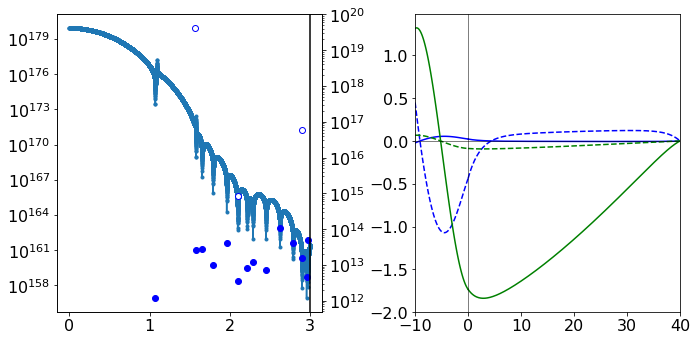

In [154]:
# Run the solution
qs=np.r_[0.4]/nm
approxroots,approxsolns=findmodes(
    q=qs,wmax=3*meV,dw=1e-4*meV, inspect=[1]
)

In [155]:
# Run the solution
qs=np.linspace(.01e9,1e9,num=60)
approxroots,approxsolns=findmodes(
    q=qs,wmax=4*meV,dw=1e-4*meV, inspect=False
)

Solving at q [1/nm]:  0.01
   32  potential roots to examine
brent imprv  0.999999939945
brent imprv  0.999951553179
brent imprv  0.006098284432
brent imprv  0.00155863010462
brent imprv  0.000269681709677
brent imprv  3.53633919654e-05
brent imprv  4.27170173442e-05
brent imprv  9.81869471958e-05
brent imprv  7.96246805461e-05
brent imprv  0.000110442265427
brent imprv  0.000115946702228
brent imprv  0.000300625126615
brent imprv  0.000620691514206
brent imprv  0.000172705112779
brent imprv  0.000125358729905
brent imprv  0.000559016461051
brent imprv  0.0171111939005
brent imprv  0.000310098909075
brent imprv  0.000344846572292
brent imprv  0.000505791578551
brent imprv  0.000519123725268
brent imprv  0.000349226604981
brent imprv  0.000889245715652
brent imprv  0.000157147726627
brent imprv  0.000382473578944
brent imprv  0.00069200635305
brent imprv  0.000201993621583
brent imprv  0.00430585040459
brent imprv  0.00507298336356
brent imprv  0.00239785464782
brent imprv  0.0002354469

   30  potential roots to examine
brent imprv  0.999999886939
brent imprv  0.000150467096357
brent imprv  0.999999996978
brent imprv  0.000150450688376
brent imprv  0.011064190088
brent imprv  7.67628276697e-05
brent imprv  3.23828606333e-05
brent imprv  0.00681240971134
brent imprv  3.99348118481e-05
brent imprv  6.77080333359e-05
brent imprv  9.01799757719e-05
brent imprv  6.72532644432e-05
brent imprv  0.000194328634491
brent imprv  0.000287753911192
brent imprv  0.00123281068338
brent imprv  0.000315246004502
brent imprv  0.000507602433228
brent imprv  1.24676397412e-05
brent imprv  0.000342811070632
brent imprv  0.000382960270455
brent imprv  0.000545763983093
brent imprv  0.0225439040853
brent imprv  0.00649175962692
brent imprv  0.000627940793443
brent imprv  0.000125009477618
brent imprv  0.000566336921271
brent imprv  0.000132997338293
brent imprv  0.000453517389888
brent imprv  0.00204861856999
brent imprv  0.000269963608398
Solving at q [1/nm]:  0.161016949153
   30  potenti

brent imprv  0.000182010962426
brent imprv  0.0229040763611
brent imprv  0.000611195680544
brent imprv  0.000609605624219
brent imprv  0.00324437270236
brent imprv  5.08490996739e-05
brent imprv  0.000322242303873
brent imprv  0.000277764021086
brent imprv  0.000273988184842
brent imprv  0.000598902272362
brent imprv  0.00397848177708
brent imprv  5.46799343963e-05
brent imprv  2.30442711545e-05
brent imprv  0.000584985456949
brent imprv  0.000584996637599
brent imprv  0.000239306463085
brent imprv  0.000672477079217
brent imprv  0.000175182953588
brent imprv  0.000275774871237
brent imprv  0.00199943898198
Solving at q [1/nm]:  0.295254237288
   30  potential roots to examine
brent imprv  0.999995185757
brent imprv  0.000522749924794
brent imprv  0.999999473749
brent imprv  0.000115088928799
brent imprv  8.35023797826e-06
brent imprv  0.000363152600191
brent imprv  0.0475026192726
brent imprv  1.91012475822e-05
brent imprv  0.000297334043334
brent imprv  0.000378235328889
brent imprv 

brent imprv  0.000695719009464
brent imprv  0.000220228841313
brent imprv  0.00124781481053
brent imprv  0.00818493962609
brent imprv  0.000322915423793
brent imprv  0.000230025215912
brent imprv  0.000776815110286
brent imprv  0.0013316398248
Solving at q [1/nm]:  0.446271186441
   24  potential roots to examine
brent imprv  4.81727478534e-05
brent imprv  0.000161959187919
brent imprv  0.000542061700816
brent imprv  0.00011312860734
brent imprv  0.000380896115578
brent imprv  0.103532591565
brent imprv  0.00457904150411
brent imprv  0.000454861243133
brent imprv  0.000243363477062
brent imprv  0.000119544943112
brent imprv  6.14634801502e-05
brent imprv  0.000380795278435
brent imprv  0.000269361751471
brent imprv  0.000103594931027
brent imprv  0.036039131863
brent imprv  0.000837869515106
brent imprv  3.56301239613e-05
brent imprv  0.00042904856041
brent imprv  0.00202734124493
brent imprv  0.000604720274655
brent imprv  0.00393703529725
brent imprv  0.0021570205532
brent imprv  0.0

   16  potential roots to examine
brent imprv  0.00355418759496
brent imprv  4.7697906197e-05
brent imprv  0.999998572621
brent imprv  0.000259300005529
brent imprv  0.0113321132286
brent imprv  0.000373541159248
brent imprv  0.000595964792176
brent imprv  5.64859687317e-05
brent imprv  0.00085147835665
brent imprv  0.010599538501
brent imprv  0.0141637540095
brent imprv  5.54721284523e-05
brent imprv  0.000347426854562
brent imprv  0.000330885272648
brent imprv  7.03856940492e-05
brent imprv  0.00141571491952
Solving at q [1/nm]:  0.664406779661
   16  potential roots to examine
brent imprv  8.38691343262e-05
brent imprv  5.03960831522e-06
brent imprv  0.999994162345
brent imprv  0.000135079693974
brent imprv  0.00407927488979
brent imprv  0.000167424649117
brent imprv  0.000591467925847
brent imprv  0.000699053680296
brent imprv  0.000920659303185
brent imprv  0.000457469865853
brent imprv  0.0116204678166
brent imprv  0.00123341314239
brent imprv  0.00157154899829
brent imprv  0.000

brent imprv  0.999953843492
brent imprv  0.997690509794
brent imprv  0.997684595682
brent imprv  0.997232676777
brent imprv  0.99721504971
brent imprv  1.0
brent imprv  0.999950599724
brent imprv  0.996495031762
brent imprv  0.999297393086
brent imprv  1.0
brent imprv  1.0
brent imprv  0.997719363285
brent imprv  0.998147992486
brent imprv  0.99988707099
brent imprv  0.998253795461
brent imprv  0.99848704177
brent imprv  0.996838253786
brent imprv  0.997846619257
brent imprv  0.998070482882
brent imprv  0.999232408812
brent imprv  0.999378300965
brent imprv  0.999932268512
brent imprv  0.998797288893
brent imprv  0.999753111833
brent imprv  0.999977262694
brent imprv  0.999421691734
brent imprv  0.999952260417
brent imprv  0.997770109252
brent imprv  1.0
brent imprv  0.999851234138
brent imprv  0.998772157436
brent imprv  1.0
brent imprv  0.999454116808
brent imprv  1.0
brent imprv  1.0
brent imprv  0.998269306305
brent imprv  0.998856915054
brent imprv  0.999439271394
brent imprv  0.9

Text(0.5,0,'In-plane wavevector [1/nm]')

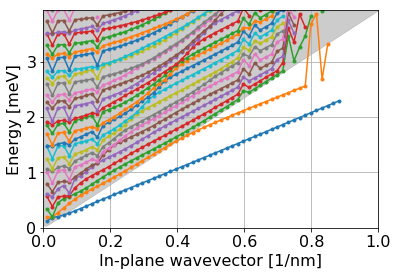

In [156]:
# Plot it
plt.figure()
v1=float(sqrt(c44A/pA).subs(numerics))
plt.fill_betweenx(v1*qs/meV,qs*nm,linewidth=.5,color='k',alpha=.2)
plt.plot(qs*nm,approxroots/meV,'.-')

#v2=float(sqrt(c44G/pG).subs(numerics))
#plt.plot(qs*nm,v2*qs/meV,linewidth=.5,color='k')

plt.xlim(0,qs[-1]*nm)
plt.ylim(0,v1*qs[-1]/meV)
#plt.ylim(-1,37)
#plt.xlim(0,6.26)
#plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
#plt.yticks([0,5,10,15,20,25,30,35])
plt.grid(True)
plt.ylabel("Energy [meV]")
plt.xlabel("In-plane wavevector [1/nm]")

# Unclean

(2.19336088134+0j)
[9.2908693787289725e+24, 9.2908693789731017e+24, 4.7612046741637784e+28, 4.761204674163803e+28]
norm 1.0
{{D^{+}_{+1A}}: (0.70710673632237719+0j), {D^{+}_{-1A}}: (-0.00025188796688876291-4.9156347948140254e-08j), {D^{-}_{+1A}}: (-0.0002898432711707288+0.70710667691890294j), {D^{-}_{-1A}}: (5.4092612158218008e-08-0.0002518879658770576j)}


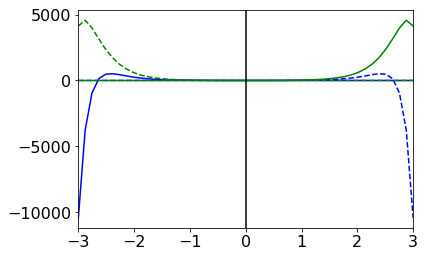

In [597]:
def _(q,w):
    w=w+0j
    print(w*hbar/e*1e3)
    en,ev=np.linalg.eig(l_m(q,w))
    print(sorted(np.abs(en)))
    coeffs=dict(zip([DApp,DApm,DAmp,DAmm],ev[:,np.argmin(np.abs(en))]))
    print("norm",np.sum(np.abs([v for v in coeffs.values()])**2))
    print(coeffs)
    bsubs={betaAm:l_betaAm(q,w),betaAp:l_betaAp(q,w)}
    dsubs={deltaAm:l_deltaAm(q,w),deltaAp:l_deltaAp(q,w)}
    lux,luz=[lambdify(z,u_alnslab(i).subs(coeffs).subs(x,0).subs(dsubs).subs(bsubs)) for i in [x,z]]
    zn=np.linspace(-3*nm,3*nm)
    plt.figure()
    plt.plot(zn/nm,lux(zn).real,'b')
    plt.plot(zn/nm,lux(zn).imag,'b--')
    plt.plot(zn/nm,luz(zn).real,'g')
    plt.plot(zn/nm,luz(zn).imag,'g--')
    plt.xlim(np.min(zn/nm),np.max(zn/nm))
    plt.ylim(-np.max(np.abs(plt.ylim())),np.min(np.abs(plt.ylim())))
    plt.axvline(0,color='k')
    return lux,luz
lux,luz=_(4.206/nm,approxroots[0,2])

In [ ]:
plt.plot()

In [ ]:
np.linalg.eig(l_m(.31/nm,approxroots[0,2]))

In [236]:
np.pi/l_betaAm(.31/nm,approxroots[0,3]) 

In [237]:
l_deltaAm(.31/nm,approxroots[0,3])

NameError: name 'l_deltaAm' is not defined

In [ ]:
eigvals()

In [106]:
def _():
    qs=np.linspace(.1e9,6.26e9)
    qs=np.array([5.002857e9,5.1285e9])
    #qs=np.array([.5e9])
    #qs=np.array([0.001e9])
    approxroots=[]
    for q in qs:
        w=e/hbar*np.linspace(.000001e-3,39e-3,10000,dtype=complex)
        d=np.linalg.det(dm(q,w).T)
        print(np.angle(d))
        print(np.angle(d) % np.pi)
        ifim=np.abs(np.abs(np.angle(d))-np.pi/2)<.1
        d[ifim]=d[ifim].imag
        d[~ifim]=d[~ifim].real
        
        # wont find degenerate roots
        approxroots+=[w[np.concatenate([[False],np.abs(np.diff(np.sign(d)))==2])].real]
        #print(approxroots*hbar/e*1e3)

        plt.plot(hbar*w.real/e*1e3,d,'.-')
        plt.axhline(0,color='k')
        plt.ylim(-1e40,1e40)
        
    approxroots=np.array([np.concatenate([ar,[np.NaN]*12])[:12] for ar in approxroots])
    dw=np.diff(w)[0].real
    if 0:
        for iq,q in enumerate(qs):
            for i,ar in enumerate(approxroots[iq]):
                #print("ar ", ar)
                res=brentq(lambda w:np.linalg.det(dm(q,w+0j).T).real,ar-dw,ar+dw)
                #print("res",res)
                approxroots[iq][i]=res
    plt.plot(approxroots*hbar/e*1e3,approxroots*hbar/e*1e3*0,'ro')
    #print(approxroots*hbar/e*1e3)
    plt.figure()
    plt.plot(qs/1e9,approxroots*hbar/e*1e3,'.-')
    plt.ylim(0,37)
    plt.xlim(0,6.26)
    plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
    plt.yticks([0,5,10,15,20,25,30,35])
    plt.grid(True)
    return approxroots
approxroots=_()

AttributeError: 'NoneType' object has no attribute 'T'

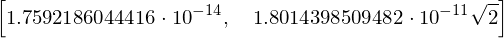

In [265]:
uxA=uxA.subs({DApp:0,DApm:0,DAmp:0})
uzA=uzA.subs({DApp:0,DApm:0,DAmp:0})
domeq=[simplify((delT(uA,i)+p*w**2*uA(i))/exp(I*q*x)/exp(-I*betaAm*z)/DAmm).subs(csubs['AlN']) for i in [x, z]]
domeq
[d.subs(betasubsR).subs(deltasubsR).subs(numerics).subs(q,.001e9).subs(w,5e-3*e/hbar)/(1e9)**3 for d in domeq]

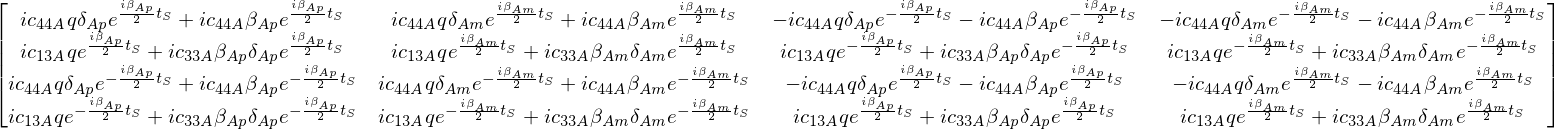

In [294]:
np.angle(np.linalg.det(dm(0.0001e9,e/hbar*5e-3+0j)))

In [332]:
np.linalg.det(dm(0.5e9,e/hbar*2e-3+0j))

(-5.6027313059810692e-06-31274463019.346455j)

In [336]:
betaAm.subs(betasubsR).subs(numerics).subs({q:0.5e9,w:e/hbar*2e-3+0j})

In [271]:
from scipy.optimize import brentq

In [295]:
-3.13 % np.pi

In [323]:
np.angle(np.exp(1j*1.9*np.pi))

[  0.00000000e+00   3.14159265e+00   3.14159265e+00 ...,  -8.18789481e-16
  -2.77555756e-16  -5.82867088e-16]
[ 0.          0.          0.         ...,  3.14159265  3.14159265
  3.14159265]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   6.93889390e-17
   7.21644966e-16  -3.05311332e-16]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   6.93889390e-17
   7.21644966e-16   3.14159265e+00]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,  -6.52256027e-16
   9.71445147e-17   6.93889390e-17]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   3.14159265e+00
   9.71445147e-17   6.93889390e-17]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,  -2.49800181e-16
   8.60422844e-16   3.05311332e-16]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   3.14159265e+00
   8.60422844e-16   3.05311332e-16]


/home/sam/miniconda3/lib/python3.6/site-packages/numpy/core/numeric.py:531: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,  -2.49800181e-16
   2.77555756e-17   4.16333634e-16]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   3.14159265e+00
   2.77555756e-17   4.16333634e-16]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,  -8.32667268e-17
   2.49800181e-16   0.00000000e+00]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   3.14159265e+00
   2.49800181e-16   0.00000000e+00]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   1.38777878e-16
   2.77555756e-16   0.00000000e+00]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   1.38777878e-16
   2.77555756e-16   0.00000000e+00]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   5.55111512e-17
   1.38777878e-16   2.49800181e-16]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,   5.55111512e-17
   1.38777878e-16   2.49800181e-16]
[  0.00000000e+00   0.00000000e+00   0.00000000e+00 ...,  -4.16333634e-16
  -1.38777878e-16  -1.38777878e-16]
[ 0.      

[ 0.          0.          0.         ...,  1.57079633  1.57079633
  1.57079633]
[ 0.          0.          0.         ...,  1.57079633  1.57079633
  1.57079633]
[ 0.          0.          0.         ...,  1.57079633  1.57079633
  1.57079633]
[ 0.          0.          0.         ...,  1.57079633  1.57079633
  1.57079633]
[ 0.          0.          0.         ..., -1.57079633 -1.57079633
 -1.57079633]
[ 0.          0.          0.         ...,  1.57079633  1.57079633
  1.57079633]
[ 0.          0.          0.         ..., -1.57079633 -1.57079633
 -1.57079633]
[ 0.          0.          0.         ...,  1.57079633  1.57079633
  1.57079633]


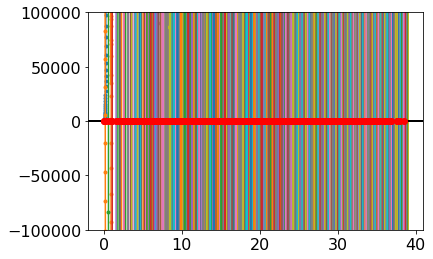

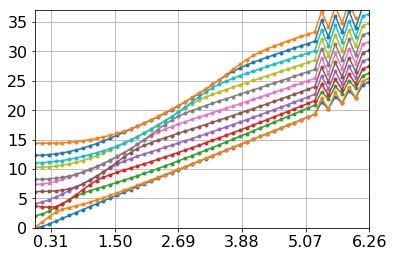

In [331]:
def _():
    qs=np.linspace(.01e9,6.26e9)
    #qs=np.array([5.07e9])
    #qs=np.array([.5e9])
    #qs=np.array([0.001e9])
    approxroots=[]
    for q in qs:
        w=e/hbar*np.linspace(.000001e-3,39e-3,10000,dtype=complex)
        d=np.linalg.det(dm(q,w).T)
        print(np.angle(d))
        print(np.angle(d) % np.pi)
        ifim=np.abs(np.abs(np.angle(d))-np.pi/2)<.1
        d[ifim]=d[ifim].imag
        d[~ifim]=d[~ifim].real
        
        # wont find degenerate roots
        approxroots+=[w[np.concatenate([[False],np.abs(np.diff(np.sign(d)))==2])].real]
        #print(approxroots*hbar/e*1e3)

        plt.plot(hbar*w.real/e*1e3,d,'.-')
        plt.axhline(0,color='k')
        plt.ylim(-1e5,1e5)
        
    approxroots=np.array([np.concatenate([ar,[np.NaN]*12])[:12] for ar in approxroots])
    dw=np.diff(w)[0].real
    if 0:
        for iq,q in enumerate(qs):
            for i,ar in enumerate(approxroots[iq]):
                #print("ar ", ar)
                res=brentq(lambda w:np.linalg.det(dm(q,w+0j).T).real,ar-dw,ar+dw)
                #print("res",res)
                approxroots[iq][i]=res
    plt.plot(approxroots*hbar/e*1e3,approxroots*hbar/e*1e3*0,'ro')
    #print(approxroots*hbar/e*1e3)
    plt.figure()
    plt.plot(qs/1e9,approxroots*hbar/e*1e3,'.-')
    plt.ylim(0,37)
    plt.xlim(0,6.26)
    plt.xticks([.31,1.5,2.69,3.88,5.07,6.26])
    plt.yticks([0,5,10,15,20,25,30,35])
    plt.grid(True)
    return approxroots
approxroots=_()

In [84]:
from scipy.linalg import eigvalsh as sp_eigvalsh

In [87]:
tempmat=dm(5.07e9,approxroots[0][0]+0j)
tempmat[0,:]=[1,0,0,0]
sam=np.linalg.lstsq(tempmat,[1,0,0,0])[0]
print(tempmat)
sam

[[  1.00000000e+00 +0.00000000e+00j   0.00000000e+00 +0.00000000e+00j
    0.00000000e+00 +0.00000000e+00j   0.00000000e+00 +0.00000000e+00j]
 [  0.00000000e+00 -3.99412304e-02j   0.00000000e+00 -2.81349826e-07j
    0.00000000e+00 +1.93736587e+08j   0.00000000e+00 +5.30889360e+12j]
 [ -9.43693766e+07 +0.00000000e+00j  -3.18642444e+12 +0.00000000e+00j
   -1.39764663e-02 +0.00000000e+00j   1.95523537e-07 +0.00000000e+00j]
 [  0.00000000e+00 -1.31015645e+08j   0.00000000e+00 -2.22749973e+12j
    0.00000000e+00 +5.90622414e-02j   0.00000000e+00 +6.70552850e-07j]]


array([  3.51854648e-16 -5.25135784e-29j,
        -1.37933544e-20 +2.05862261e-33j,
        -3.72338537e-25 -3.83015360e-34j,   1.84682753e-29 -1.04971524e-29j])

In [88]:
tempmat@sam

array([  3.51854648e-16 -5.25135784e-29j,
         5.57282651e-17 +1.18570034e-17j,
         1.07471778e-08 -1.60397173e-21j,  -2.29451906e-21 -1.53737706e-08j])

In [86]:
tempmat=dm(5.07e9,approxroots[0][1]+0j)
tempmat[0,:]=[1,0,0,0]
sam=np.linalg.lstsq(tempmat,[1,0,0,0])[0]
sam

array([  3.51861468e-16 -1.25694317e-28j,
        -1.37936174e-20 +4.92744996e-33j,
        -3.72352624e-25 +3.09394386e-34j,   3.93816487e-29 +8.47458233e-30j])

In [195]:
uA(x)

In [174]:
sp_eigvalsh(dm(5.07e9,approxroots[0][0]+0j))

array([ -7.79535336e+10,  -1.81550085e+05,   1.81635176e+05,
         7.79535336e+10])

In [165]:
uA(x)

In [163]:
deltaAm approxroots

array([[  2.83824513e+13,   3.05107581e+13,   3.12912333e+13,
          3.25245133e+13,   3.41277273e+13,   3.60126298e+13,
          3.64372087e+13,   3.80992506e+13,   4.03235527e+13,
          4.26395140e+13,   4.50173116e+13,   4.74395684e+13,
          4.98972797e+13]])

In [386]:
approxroots/e*hbar*1e3

array([[ 18.53491303,  19.71257124,  20.20988501,  20.99536803,
         22.0982452 ,  23.4140177 ,  24.86949331,  26.41098701,
         28.00041826,  29.61165019,  31.22570475,  32.82412948]])

In [407]:
approxroots[0]*hbar/e*1e3

array([ 18.53491303,  19.71257124,  20.20988501,  20.99536803,
        22.0982452 ,  23.4140177 ,  24.86949331,  26.41098701,
        28.00041826,  29.61165019,  31.22570475,  32.82412948])

array([ 18.5372005 ,  20.03783102,  20.83228247,  21.97982346,
        23.48045397,  24.89281211,  26.39344262,  28.07061791,
        29.74779319,  31.24842371,  32.92559899])

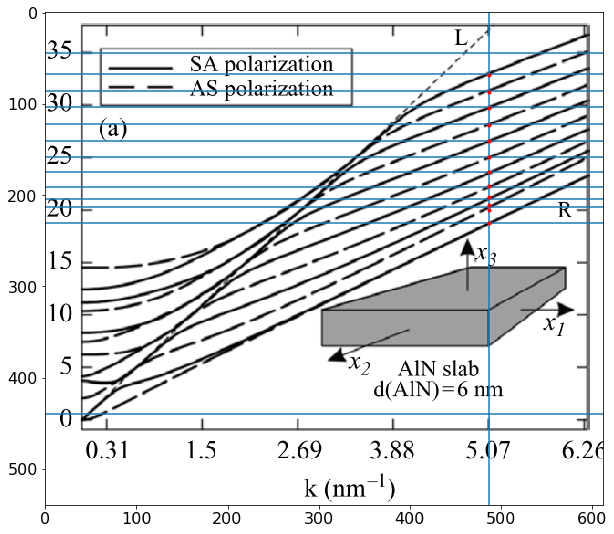

In [410]:
img=plt.imread("EP_Fig4a.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axvline(486.25)
ys=np.array([440,230,213,204,191,174,158,141,122,103,86,67,43.5])
for y in ys:
    plt.axhline(y)
for y in approxroots[0]*hbar/e*1e3:
    plt.plot(486.25,y*(ys[-1]-ys[0])/(35)+ys[0],'r.')
35*(ys[1:-1]-ys[0])/(ys[-1]-ys[0])

# pFET

###

In [53]:
uxG=\
    DGpp*mode.subs(beta, betaGp)+DGpm*mode.subs(beta, betaGm)+\
    DGmp*mode.subs(beta,-betaGp)+DGmm*mode.subs(beta,-betaGm)
uzG=\
    DGpp*deltaGp*mode.subs(beta, betaGp)+DGpm*deltaGm*mode.subs(beta, betaGm)+\
    DGmp*deltaGp*mode.subs(beta,-betaGp)+DGmm*deltaGm*mode.subs(beta,-betaGm)
uxA=\
    DApm*mode.subs(beta, betam)+\
    DAmp*mode.subs(beta,-betap)
uzA=\
    DApm*deltaAm*mode.subs(beta, betaAm)+\
    DAmp*deltaAp*mode.subs(beta,-betaAp)

In [54]:
uxA

In [56]:
tG=symbols("{t_G}")

In [57]:
topboundT=[T(uG,i,z).subs(x,0).subs(z,tG).subs(csubs['GaN']) for i in [x,z]]

In [58]:
midboundT=[T(uG,i,z).subs(x,0).subs(z,0).subs(csubs['GaN'])-T(uA,i,z).subs(x,0).subs(z,0).subs(csubs['AlN']) for i in [x,z]]

In [59]:
midboundu=[uG(i).subs(x,0).subs(z,0).subs(csubs['GaN'])-uA(i).subs(x,0).subs(z,0).subs(csubs['AlN']) for i in [x,z]]

In [60]:
midboundu

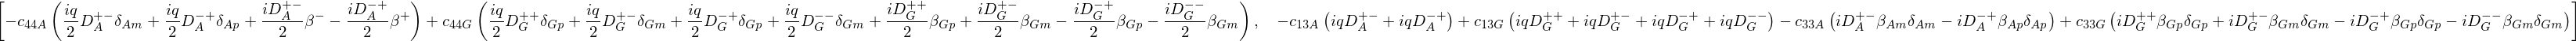

In [61]:
midboundT